# 01 — Data Collection and Validation

This notebook constructs two separate datasets for the Nordic Wind Decision System:

1. **Main historical panel:** homogeneous D2 fixed-lead forecasts from every provider that supplies usable historical wind forecasts over the common period.
2. **Exact-run robustness panel:** complete model runs selected as available by the 11:00 Europe/Copenhagen D-1 decision time.

The provider registry deliberately distinguishes:

- **mandatory long-history core providers:** GFS, ICON-EU and ECMWF;
- **candidate providers:** DMI, ARPEGE, UKMO, GEM, JMA, CMA and BOM.

Candidate providers are selected solely from data availability and wind-variable coverage. A provider is not forced into the main panel when the Previous Runs archive contains only null wind fields. The exact-run dataset remains separate and may contain a broader source set in the recent period.

The main panel supports individual LightGBM experts, equal weighting, constrained weighting, dynamic weighting, stacking and pooled modelling.


In [1]:
from __future__ import annotations

import hashlib
import json
import math
import time
import warnings
from datetime import date, datetime, time as dt_time, timedelta, timezone
from pathlib import Path
from typing import Any, Iterable, Sequence
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 220)

warnings.filterwarnings("ignore", category=FutureWarning)


## 1. Configuration


In [2]:
RUN_MODE = "FULL"  # "AUDIT" or "FULL"
RUN_EXACT_ROBUSTNESS = True

# Main D2 Previous Runs panel.
MAIN_FULL_START_DATE = "2024-07-05"
MAIN_AUDIT_START_DATE = "2024-07-05"
MAIN_AUDIT_END_DATE = "2024-07-12"  # exclusive

# Exact Single Runs panel.
EXACT_FULL_START_DATE = "2025-09-01"
EXACT_AUDIT_START_DATE = "2026-04-01"
EXACT_AUDIT_END_DATE = "2026-04-04"  # exclusive

SETTLEMENT_SAFETY_LAG_DAYS = 16
PRICE_AREAS = ["DK1", "DK2"]
LOCAL_TIMEZONE = "Europe/Copenhagen"
DECISION_LOCAL_HOUR = 11
RANDOM_SEED = 42

MIN_CORE_SOURCE_COVERAGE = 0.99
MIN_OPTIONAL_SOURCE_COVERAGE = 0.995
MIN_COMMON_PANEL_RETENTION = 0.98

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CONFIG_PATH = PROJECT_ROOT / "configs" / "project.json"
if CONFIG_PATH.exists():
    with CONFIG_PATH.open("r", encoding="utf-8") as file:
        PROJECT_CONFIG = json.load(file)
else:
    PROJECT_CONFIG = {}

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
AUDIT_DIR = PROJECT_ROOT / "outputs" / "audits"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

for directory in [
    RAW_DIR,
    INTERIM_DIR,
    PROCESSED_DIR,
    AUDIT_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

if RUN_MODE not in {"AUDIT", "FULL"}:
    raise ValueError("RUN_MODE must be 'AUDIT' or 'FULL'.")

LOCAL_TZ = ZoneInfo(LOCAL_TIMEZONE)

if RUN_MODE == "AUDIT":
    MAIN_START_DATE = MAIN_AUDIT_START_DATE
    MAIN_END_DATE = MAIN_AUDIT_END_DATE
    EXACT_START_DATE = EXACT_AUDIT_START_DATE
    EXACT_END_DATE = EXACT_AUDIT_END_DATE
else:
    MAIN_START_DATE = MAIN_FULL_START_DATE
    settled_cutoff = (
        pd.Timestamp.now(tz=LOCAL_TIMEZONE).normalize()
        - pd.Timedelta(days=SETTLEMENT_SAFETY_LAG_DAYS)
    )
    MAIN_END_DATE = settled_cutoff.date().isoformat()
    EXACT_START_DATE = EXACT_FULL_START_DATE
    EXACT_END_DATE = MAIN_END_DATE

START_LOCAL = pd.Timestamp(MAIN_START_DATE).tz_localize(LOCAL_TZ)
END_LOCAL = pd.Timestamp(MAIN_END_DATE).tz_localize(LOCAL_TZ)
START_UTC = START_LOCAL.tz_convert("UTC")
END_UTC = END_LOCAL.tz_convert("UTC")

EXACT_START_LOCAL = pd.Timestamp(EXACT_START_DATE).tz_localize(LOCAL_TZ)
EXACT_END_LOCAL = pd.Timestamp(EXACT_END_DATE).tz_localize(LOCAL_TZ)
EXACT_START_UTC = EXACT_START_LOCAL.tz_convert("UTC")
EXACT_END_UTC = EXACT_END_LOCAL.tz_convert("UTC")

if END_UTC <= START_UTC:
    raise ValueError("The main end date must be after the start date.")

EXPECTED_HOURS = len(
    pd.date_range(
        START_UTC,
        END_UTC,
        freq="h",
        inclusive="left",
    )
)
EXPECTED_TARGET_ROWS = EXPECTED_HOURS * len(PRICE_AREAS)

print("Project root:", PROJECT_ROOT)
print("Run mode:", RUN_MODE)
print("Main local interval:", START_LOCAL, "to", END_LOCAL, "(exclusive)")
print("Exact local interval:", EXACT_START_LOCAL, "to", EXACT_END_LOCAL, "(exclusive)")
print("Expected main target rows:", EXPECTED_TARGET_ROWS)


Project root: C:\Users\chka24ac\Nordic Wind Decision System
Run mode: FULL
Main local interval: 2024-07-05 00:00:00+02:00 to 2026-06-06 00:00:00+02:00 (exclusive)
Exact local interval: 2025-09-01 00:00:00+02:00 to 2026-06-06 00:00:00+02:00 (exclusive)
Expected main target rows: 33648


## 2. Spatial weather grid and provider registry

The main dataset uses D2 forecasts. GFS, ICON-EU and ECMWF are mandatory because the audit confirms complete historical wind coverage. Other providers remain candidates and are retained only when their Previous Runs data contain a sufficiently complete wind channel.

Wind height is selected per provider:

- prefer 100 m wind when complete;
- otherwise use 10 m wind when complete;
- exclude the provider from the main wind-expert panel when neither channel is usable.

This is valid for source-specific experts because weighting combines their predictions, not identical raw feature vectors.


In [3]:
WEATHER_POINTS = pd.DataFrame(
    [
        {"point_id": "dk1_west_jutland_north", "price_area": "DK1", "latitude": 56.70, "longitude": 8.20,  "environment": "coastal",  "spatial_weight": 1.0},
        {"point_id": "dk1_west_jutland_south", "price_area": "DK1", "latitude": 55.55, "longitude": 8.35,  "environment": "coastal",  "spatial_weight": 1.0},
        {"point_id": "dk1_north_jutland",       "price_area": "DK1", "latitude": 57.10, "longitude": 9.65,  "environment": "onshore",  "spatial_weight": 1.0},
        {"point_id": "dk1_central_jutland",     "price_area": "DK1", "latitude": 56.20, "longitude": 9.20,  "environment": "onshore",  "spatial_weight": 1.0},
        {"point_id": "dk1_south_jutland",       "price_area": "DK1", "latitude": 55.15, "longitude": 9.10,  "environment": "onshore",  "spatial_weight": 1.0},
        {"point_id": "dk1_funen",               "price_area": "DK1", "latitude": 55.35, "longitude": 10.25, "environment": "onshore",  "spatial_weight": 1.0},
        {"point_id": "dk1_north_sea_west",      "price_area": "DK1", "latitude": 55.80, "longitude": 6.80,  "environment": "offshore", "spatial_weight": 1.0},
        {"point_id": "dk1_north_sea_north",     "price_area": "DK1", "latitude": 56.60, "longitude": 7.30,  "environment": "offshore", "spatial_weight": 1.0},
        {"point_id": "dk1_kattegat",            "price_area": "DK1", "latitude": 56.60, "longitude": 11.20, "environment": "offshore", "spatial_weight": 1.0},
        {"point_id": "dk2_west_zealand",        "price_area": "DK2", "latitude": 55.45, "longitude": 11.25, "environment": "onshore",  "spatial_weight": 1.0},
        {"point_id": "dk2_east_zealand",        "price_area": "DK2", "latitude": 55.65, "longitude": 12.35, "environment": "coastal",  "spatial_weight": 1.0},
        {"point_id": "dk2_south_zealand",       "price_area": "DK2", "latitude": 54.85, "longitude": 11.90, "environment": "onshore",  "spatial_weight": 1.0},
        {"point_id": "dk2_lolland_falster",     "price_area": "DK2", "latitude": 54.75, "longitude": 11.25, "environment": "coastal",  "spatial_weight": 1.0},
        {"point_id": "dk2_bornholm",            "price_area": "DK2", "latitude": 55.13, "longitude": 14.92, "environment": "onshore",  "spatial_weight": 1.0},
        {"point_id": "dk2_baltic_west",         "price_area": "DK2", "latitude": 54.70, "longitude": 12.50, "environment": "offshore", "spatial_weight": 1.0},
        {"point_id": "dk2_baltic_east",         "price_area": "DK2", "latitude": 55.00, "longitude": 13.50, "environment": "offshore", "spatial_weight": 1.0},
        {"point_id": "dk2_oresund",             "price_area": "DK2", "latitude": 55.75, "longitude": 12.80, "environment": "offshore", "spatial_weight": 1.0},
    ]
)

MAIN_WEATHER_MODELS = {
    "gfs": {
        "api_model": "gfs_global",
        "required": True,
        "provider": "NOAA",
    },
    "icon_eu": {
        "api_model": "icon_eu",
        "required": True,
        "provider": "DWD",
    },
    "ecmwf": {
        "api_model": "ecmwf_ifs025",
        "required": True,
        "provider": "ECMWF",
    },
    "dmi": {
        "api_model": "dmi_harmonie_arome_europe",
        "required": False,
        "provider": "DMI",
    },
    "arpege_europe": {
        "api_model": "meteofrance_arpege_europe",
        "required": False,
        "provider": "Météo-France",
    },
    "ukmo_global": {
        "api_model": "ukmo_global_deterministic_10km",
        "required": False,
        "provider": "UK Met Office",
    },
    "gem_global": {
        "api_model": "gem_global",
        "required": False,
        "provider": "Environment Canada",
    },
    "jma_gsm": {
        "api_model": "jma_gsm",
        "required": False,
        "provider": "JMA",
    },
    "cma_grapes": {
        "api_model": "cma_grapes_global",
        "required": False,
        "provider": "CMA",
    },
    "bom_access": {
        "api_model": "bom_access_global",
        "required": False,
        "provider": "BOM",
    },
}

EXACT_WEATHER_MODELS = {
    "gfs": {
        "api_model": "gfs_global",
        "run_hours_utc": [0, 6, 12, 18],
        "availability_lag_hours": 6,
    },
    "icon_eu": {
        "api_model": "icon_eu",
        "run_hours_utc": [0, 6, 12, 18],
        "availability_lag_hours": 4,
    },
    "ecmwf": {
        "api_model": "ecmwf_ifs025",
        "run_hours_utc": [0, 6, 12, 18],
        "availability_lag_hours": 6,
    },
    "dmi": {
        "api_model": "dmi_harmonie_arome_europe",
        "run_hours_utc": list(range(0, 24, 3)),
        "availability_lag_hours": 4,
    },
    "arpege_europe": {
        "api_model": "meteofrance_arpege_europe",
        "run_hours_utc": [0, 6, 12, 18],
        "availability_lag_hours": 5,
    },
    "ukmo_global": {
        "api_model": "ukmo_global_deterministic_10km",
        "run_hours_utc": [0, 6, 12, 18],
        "availability_lag_hours": 6,
    },
    "gem_global": {
        "api_model": "gem_global",
        "run_hours_utc": [0, 12],
        "availability_lag_hours": 6,
    },
    "jma_gsm": {
        "api_model": "jma_gsm",
        "run_hours_utc": [0, 6, 12, 18],
        "availability_lag_hours": 6,
    },
    "cma_grapes": {
        "api_model": "cma_grapes_global",
        "run_hours_utc": [0, 6, 12, 18],
        "availability_lag_hours": 6,
    },
    "bom_access": {
        "api_model": "bom_access_global",
        "run_hours_utc": [0, 6, 12, 18],
        "availability_lag_hours": 6,
    },
}

EXACT_ACTIVE_ALIASES = [
    "gfs",
    "icon_eu",
    "ecmwf",
    "dmi",
    "arpege_europe",
    "ukmo_global",
    "cma_grapes",
]

EXACT_WEATHER_MODELS = {
    model_alias: specification
    for model_alias, specification
    in EXACT_WEATHER_MODELS.items()
    if model_alias in EXACT_ACTIVE_ALIASES
}

WEATHER_VARIABLES = [
    "wind_speed_100m",
    "wind_direction_100m",
    "wind_speed_10m",
    "wind_direction_10m",
    "temperature_2m",
    "pressure_msl",
]

PREVIOUS_RUN_DAY = 2
PREVIOUS_RUN_VARIABLES = [
    f"{variable}_previous_day{PREVIOUS_RUN_DAY}"
    for variable in WEATHER_VARIABLES
]

display(WEATHER_POINTS)
display(pd.DataFrame(MAIN_WEATHER_MODELS).T)


,point_id,price_area,latitude,longitude,environment,spatial_weight
0,dk1_west_jutland_north,DK1,56.70,8.20,coastal,1.0
1,dk1_west_jutland_south,DK1,55.55,8.35,coastal,1.0
2,dk1_north_jutland,DK1,57.10,9.65,onshore,1.0
3,dk1_central_jutland,DK1,56.20,9.20,onshore,1.0
4,dk1_south_jutland,DK1,55.15,9.10,onshore,1.0
5,dk1_funen,DK1,55.35,10.25,onshore,1.0
6,dk1_north_sea_west,DK1,55.80,6.80,offshore,1.0
7,dk1_north_sea_north,DK1,56.60,7.30,offshore,1.0
8,dk1_kattegat,DK1,56.60,11.20,offshore,1.0
9,dk2_west_zealand,DK2,55.45,11.25,onshore,1.0


,api_model,required,provider
gfs,gfs_global,True,NOAA
icon_eu,icon_eu,True,DWD
ecmwf,ecmwf_ifs025,True,ECMWF
dmi,dmi_harmonie_arome_europe,False,DMI
arpege_europe,meteofrance_arpege_europe,False,Météo-France
ukmo_global,ukmo_global_deterministic_10km,False,UK Met Office
gem_global,gem_global,False,Environment Canada
jma_gsm,jma_gsm,False,JMA
cma_grapes,cma_grapes_global,False,CMA
bom_access,bom_access_global,False,BOM


## 3. HTTP, caching and provenance utilities


In [4]:
class DataDownloadError(RuntimeError):
    pass


def stable_hash(value: Any) -> str:
    encoded = json.dumps(
        value,
        sort_keys=True,
        default=str,
        separators=(",", ":"),
    ).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()[:16]


def request_json(
    url: str,
    params: dict[str, Any] | None = None,
    timeout: int = 180,
    max_retries: int = 6,
    pause_seconds: float = 1.0,
) -> dict[str, Any] | list[Any]:
    last_error: Exception | None = None
    last_status: int | None = None
    last_body = ""

    for attempt in range(max_retries):
        try:
            response = requests.get(
                url,
                params=params,
                timeout=timeout,
                headers={
                    "User-Agent": "nordic-wind-decision-system/0.2"
                },
            )
            last_status = response.status_code
            last_body = response.text[:1000]

            if response.status_code == 429:
                retry_after = float(
                    response.headers.get(
                        "Retry-After",
                        pause_seconds * (attempt + 1),
                    )
                )
                time.sleep(max(retry_after, pause_seconds))
                continue

            response.raise_for_status()
            return response.json()

        except (requests.RequestException, ValueError) as exc:
            last_error = exc
            if attempt == max_retries - 1:
                break
            time.sleep(pause_seconds * (2 ** attempt))

    raise DataDownloadError(
        f"Request failed after {max_retries} attempts: {url}; "
        f"status={last_status}; body={last_body}"
    ) from last_error


def request_json_cached(
    url: str,
    params: dict[str, Any],
    cache_path: Path,
    force_refresh: bool = False,
) -> dict[str, Any] | list[Any]:
    if cache_path.exists() and not force_refresh:
        with cache_path.open("r", encoding="utf-8") as file:
            cached = json.load(file)
        return cached["payload"]

    payload = request_json(url=url, params=params)
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    record = {
        "retrieved_at_utc": datetime.now(timezone.utc).isoformat(),
        "request_url": url,
        "request_params": params,
        "payload": payload,
    }

    with cache_path.open("w", encoding="utf-8") as file:
        json.dump(record, file, ensure_ascii=False)

    return payload


def trim_utc(
    frame: pd.DataFrame,
    timestamp_column: str,
    start_utc: pd.Timestamp = START_UTC,
    end_utc: pd.Timestamp = END_UTC,
) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()

    output = frame.copy()
    output[timestamp_column] = pd.to_datetime(
        output[timestamp_column],
        utc=True,
        errors="coerce",
    )

    return output.loc[
        output[timestamp_column].ge(start_utc)
        & output[timestamp_column].lt(end_utc)
    ].copy()


## 4. Energinet source registry and live metadata audit

The notebook records current source metadata before downloading observations. This makes dataset replacements and resolution changes visible in the Git-tracked audit outputs.


In [5]:
EDS_BASE = "https://api.energidataservice.dk"

SOURCE_REGISTRY = pd.DataFrame(
    [
        {
            "dataset": "ProductionConsumptionSettlement",
            "role": "settlement target",
            "required": True,
            "information_time_use": "target only",
        },
        {
            "dataset": "DayAheadPrices",
            "role": "current day-ahead price",
            "required": True,
            "information_time_use": "market outcome/context",
        },
        {
            "dataset": "Elspotprices",
            "role": "historical day-ahead price fallback",
            "required": False,
            "information_time_use": "market outcome/context",
        },
        {
            "dataset": "ImbalancePrice",
            "role": "current imbalance price",
            "required": True,
            "information_time_use": "commercial outcome",
        },
        {
            "dataset": "RegulatingBalancePowerdata",
            "role": "historical imbalance fallback",
            "required": False,
            "information_time_use": "commercial outcome",
        },
        {
            "dataset": "Forecasts_Hour",
            "role": "Energinet operational wind forecast benchmark",
            "required": False,
            "information_time_use": "benchmark; revision timing to audit",
        },
    ]
)


def fetch_eds_metadata(dataset: str) -> dict[str, Any]:
    payload = request_json(f"{EDS_BASE}/meta/Dataset/{dataset}")
    if not isinstance(payload, dict):
        raise DataDownloadError(
            f"Unexpected metadata response for {dataset}."
        )
    return payload


metadata_rows: list[dict[str, Any]] = []
metadata_full: dict[str, Any] = {}

for dataset in SOURCE_REGISTRY["dataset"]:
    try:
        metadata = fetch_eds_metadata(dataset)
        metadata_full[dataset] = metadata
        metadata_rows.append(
            {
                "dataset": dataset,
                "title": metadata.get("title"),
                "resolution": metadata.get("resolution"),
                "data_from": metadata.get("dataFrom"),
                "active": metadata.get("active"),
                "last_metadata_update": metadata.get(
                    "lastMetadataUpdate"
                ),
                "metadata_status": "OK",
            }
        )
    except Exception as exc:
        metadata_rows.append(
            {
                "dataset": dataset,
                "metadata_status": f"ERROR: {exc!r}",
            }
        )

source_metadata_audit = SOURCE_REGISTRY.merge(
    pd.DataFrame(metadata_rows),
    on="dataset",
    how="left",
)

with (AUDIT_DIR / "energinet_source_metadata.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(metadata_full, file, indent=2, ensure_ascii=False)

source_metadata_audit.to_csv(
    AUDIT_DIR / "energinet_source_metadata_summary.csv",
    index=False,
)

display(source_metadata_audit)


,dataset,role,required,information_time_use,title,resolution,data_from,active,last_metadata_update,metadata_status
0,ProductionConsumptionSettlement,settlement target,True,target only,Production and Consumption - Settlement,1 hour (PT1H),2005-01-01T00:00:00,True,2026-06-17T09:12:52,OK
1,DayAheadPrices,current day-ahead price,True,market outcome/context,Day-Ahead Prices,15 minutes (PT15M),2025-10-01T00:00:00,True,2026-05-07T14:24:08,OK
2,Elspotprices,historical day-ahead price fallback,False,market outcome/context,Elspot Prices (Discontinued – see description),1 hour (PT1H),1999-07-01T00:00:00,True,2026-01-08T11:23:36,OK
3,ImbalancePrice,current imbalance price,True,commercial outcome,Imbalance Price,15 minutes (PT15M),2025-03-04T13:00:00,True,2026-05-06T16:29:59,OK
4,RegulatingBalancePowerdata,historical imbalance fallback,False,commercial outcome,"Regulating and Balance Power, Overall Data (Di...",1 hour (PT1H),1999-07-01T00:00:00,True,2026-03-03T12:54:19,OK
5,Forecasts_Hour,Energinet operational wind forecast benchmark,False,benchmark; revision timing to audit,"Forecast Wind and Solar Power, Hour Resolution",1 hour (PT1H),2019-10-31T00:00:00,True,2026-05-28T10:39:44,OK


## 5. Energinet download utilities


In [6]:
def parse_eds_records(
    payload: dict[str, Any] | list[Any],
) -> list[dict[str, Any]]:
    if isinstance(payload, dict):
        for key in ["records", "result", "data"]:
            value = payload.get(key)
            if isinstance(value, list):
                return value

    if isinstance(payload, list):
        return payload

    raise DataDownloadError(
        f"Unexpected Energinet payload structure: {type(payload)}"
    )


def period_chunks(
    start: pd.Timestamp,
    end: pd.Timestamp,
    days: int,
) -> list[tuple[pd.Timestamp, pd.Timestamp]]:
    chunks: list[tuple[pd.Timestamp, pd.Timestamp]] = []
    cursor = start

    while cursor < end:
        right = min(cursor + pd.Timedelta(days=days), end)
        chunks.append((cursor, right))
        cursor = right

    return chunks


def format_eds_timestamp(
    timestamp: pd.Timestamp,
) -> str:
    timestamp = pd.Timestamp(timestamp)

    if timestamp.tzinfo is None:
        raise ValueError(
            "Energinet request timestamps must be timezone-aware."
        )

    return (
        timestamp
        .tz_convert("UTC")
        .strftime("%Y-%m-%dT%H:%M")
    )


def eds_download_chunked(
    dataset: str,
    start: pd.Timestamp,
    end: pd.Timestamp,
    filters: dict[str, list[str]] | None = None,
    chunk_days: int = 31,
    force_refresh: bool = False,
) -> pd.DataFrame:
    parts: list[pd.DataFrame] = []
    chunks = period_chunks(start, end, chunk_days)

    for chunk_number, (left, right) in enumerate(
        chunks,
        start=1,
    ):
        params: dict[str, Any] = {
            "start": format_eds_timestamp(left),
            "end": format_eds_timestamp(right),
            "timezone": "UTC",
            "limit": 0,
        }

        if filters:
            params["filter"] = json.dumps(
                filters,
                separators=(",", ":"),
            )

        cache_key = stable_hash(
            {
                "dataset": dataset,
                "start": params["start"],
                "end": params["end"],
                "timezone": params["timezone"],
                "filters": filters,
            }
        )

        cache_path = (
            RAW_DIR
            / "energinet"
            / dataset
            / f"{cache_key}.json"
        )

        cache_existed_before_request = cache_path.exists()

        print(
            f"[{dataset}] chunk "
            f"{chunk_number}/{len(chunks)}: "
            f"{params['start']} to {params['end']} UTC"
        )

        payload = request_json_cached(
            url=f"{EDS_BASE}/dataset/{dataset}",
            params=params,
            cache_path=cache_path,
            force_refresh=force_refresh,
        )

        records = parse_eds_records(payload)

        if records:
            part = pd.DataFrame.from_records(records)
            part["_source_dataset"] = dataset
            part["_retrieved_from_cache"] = (
                cache_existed_before_request
                and not force_refresh
            )
            parts.append(part)

        time.sleep(0.2)

    if not parts:
        return pd.DataFrame()

    return pd.concat(parts, ignore_index=True)


def first_existing(
    columns: Iterable[str],
    candidates: Sequence[str],
) -> str:
    available = set(columns)

    for candidate in candidates:
        if candidate in available:
            return candidate

    raise KeyError(
        "None of the candidate columns exist: "
        f"{list(candidates)}"
    )


def numeric_series(
    frame: pd.DataFrame,
    column: str,
) -> pd.Series:
    return pd.to_numeric(
        frame[column],
        errors="coerce",
    )


## 6. Settled DK1/DK2 wind generation

Settlement data are used as the **target only**. They are not treated as if they were available in real time.


In [7]:
def resolve_wind_component(
    frame: pd.DataFrame,
    aggregate_candidates: list[str],
    detailed_candidate_sets: list[list[str]],
    component_name: str,
) -> tuple[pd.Series, list[str]]:
    for column in aggregate_candidates:
        if column in frame.columns:
            return numeric_series(frame, column), [column]

    for column_set in detailed_candidate_sets:
        if all(column in frame.columns for column in column_set):
            values = pd.concat(
                [
                    numeric_series(frame, column)
                    for column in column_set
                ],
                axis=1,
            ).sum(axis=1, min_count=1)
            return values, column_set

    raise KeyError(
        f"Could not construct {component_name}. "
        f"Available columns: {frame.columns.tolist()}"
    )


def prepare_actual_wind(
    frame: pd.DataFrame,
    start_utc: pd.Timestamp = START_UTC,
    end_utc: pd.Timestamp = END_UTC,
) -> pd.DataFrame:
    if frame.empty:
        raise ValueError(
            "ProductionConsumptionSettlement returned no records."
        )

    output = frame.copy()

    time_column = first_existing(
        output.columns,
        ["HourUTC", "TimeUTC", "QuarterUTC", "Minutes5UTC"],
    )
    area_column = first_existing(
        output.columns,
        ["PriceArea", "Area"],
    )

    output["timestamp_utc"] = pd.to_datetime(
        output[time_column],
        utc=True,
        errors="coerce",
    )
    output["price_area"] = output[area_column].astype(str)

    onshore, onshore_sources = resolve_wind_component(
        output,
        aggregate_candidates=[
            "OnshoreWindPower",
            "OnshoreWindPowerMWh",
        ],
        detailed_candidate_sets=[
            [
                "OnshoreWindGe50kW_MWh",
                "OnshoreWindLt50kW_MWh",
            ],
            [
                "OnshoreWindGe50kW",
                "OnshoreWindLt50kW",
            ],
        ],
        component_name="onshore wind",
    )

    offshore, offshore_sources = resolve_wind_component(
        output,
        aggregate_candidates=[
            "OffshoreWindPower",
            "OffshoreWindPowerMWh",
        ],
        detailed_candidate_sets=[
            [
                "OffshoreWindGe100MW_MWh",
                "OffshoreWindLt100MW_MWh",
            ],
            [
                "OffshoreWindGe100MW",
                "OffshoreWindLt100MW",
            ],
        ],
        component_name="offshore wind",
    )

    output["actual_onshore_wind_mwh"] = onshore
    output["actual_offshore_wind_mwh"] = offshore
    output["actual_wind_mwh"] = onshore + offshore
    output["wind_source_columns"] = (
        "onshore="
        + ",".join(onshore_sources)
        + "; offshore="
        + ",".join(offshore_sources)
    )

    result = output[
        [
            "timestamp_utc",
            "price_area",
            "actual_onshore_wind_mwh",
            "actual_offshore_wind_mwh",
            "actual_wind_mwh",
            "wind_source_columns",
        ]
    ].copy()

    result = trim_utc(
        result,
        "timestamp_utc",
        start_utc=start_utc,
        end_utc=end_utc,
    )

    return (
        result.sort_values(["timestamp_utc", "price_area"])
        .drop_duplicates(
            ["timestamp_utc", "price_area"],
            keep="last",
        )
        .reset_index(drop=True)
    )


production_raw = eds_download_chunked(
    dataset="ProductionConsumptionSettlement",
    start=START_UTC - pd.Timedelta(days=1),
    end=END_UTC + pd.Timedelta(days=1),
    filters={"PriceArea": PRICE_AREAS},
    chunk_days=7 if RUN_MODE == "AUDIT" else 31,
)

actual_wind = prepare_actual_wind(production_raw)

print("Actual wind shape:", actual_wind.shape)
display(actual_wind.head())
display(
    actual_wind.groupby("price_area")[
        "actual_wind_mwh"
    ].describe()
)


[ProductionConsumptionSettlement] chunk 1/23: 2024-07-03T22:00 to 2024-08-03T22:00 UTC
[ProductionConsumptionSettlement] chunk 2/23: 2024-08-03T22:00 to 2024-09-03T22:00 UTC
[ProductionConsumptionSettlement] chunk 3/23: 2024-09-03T22:00 to 2024-10-04T22:00 UTC
[ProductionConsumptionSettlement] chunk 4/23: 2024-10-04T22:00 to 2024-11-04T22:00 UTC
[ProductionConsumptionSettlement] chunk 5/23: 2024-11-04T22:00 to 2024-12-05T22:00 UTC
[ProductionConsumptionSettlement] chunk 6/23: 2024-12-05T22:00 to 2025-01-05T22:00 UTC
[ProductionConsumptionSettlement] chunk 7/23: 2025-01-05T22:00 to 2025-02-05T22:00 UTC
[ProductionConsumptionSettlement] chunk 8/23: 2025-02-05T22:00 to 2025-03-08T22:00 UTC
[ProductionConsumptionSettlement] chunk 9/23: 2025-03-08T22:00 to 2025-04-08T22:00 UTC
[ProductionConsumptionSettlement] chunk 10/23: 2025-04-08T22:00 to 2025-05-09T22:00 UTC
[ProductionConsumptionSettlement] chunk 11/23: 2025-05-09T22:00 to 2025-06-09T22:00 UTC
[ProductionConsumptionSettlement] chunk 1

,timestamp_utc,price_area,actual_onshore_wind_mwh,actual_offshore_wind_mwh,actual_wind_mwh,wind_source_columns
0,2024-07-04 22:00:00+00:00,DK1,1478.715066,1307.031393,2785.746459,"onshore=OnshoreWindGe50kW_MWh,OnshoreWindLt50k..."
1,2024-07-04 22:00:00+00:00,DK2,330.657406,842.593634,1173.251040,"onshore=OnshoreWindGe50kW_MWh,OnshoreWindLt50k..."
2,2024-07-04 23:00:00+00:00,DK1,1506.584243,1386.003969,2892.588212,"onshore=OnshoreWindGe50kW_MWh,OnshoreWindLt50k..."
3,2024-07-04 23:00:00+00:00,DK2,340.435414,857.292068,1197.727482,"onshore=OnshoreWindGe50kW_MWh,OnshoreWindLt50k..."
4,2024-07-05 00:00:00+00:00,DK1,1501.498585,1464.095370,2965.593955,"onshore=OnshoreWindGe50kW_MWh,OnshoreWindLt50k..."


,count,mean,std,min,25%,50%,75%,max
price_area,,,,,,,,
DK1,16824.0,1677.877796,1267.806931,0.054231,573.525773,1409.323182,2563.921502,4966.234728
DK2,16824.0,549.583726,455.759828,0.019418,143.994658,427.188712,913.060029,1582.986883


## 7. Day-ahead prices

Both the current and historical Energinet datasets are attempted. Overlapping records prefer `DayAheadPrices`.


In [8]:
PRICE_TIME_CANDIDATES = [
    "TimeUTC",
    "HourUTC",
    "QuarterUTC",
    "Minutes15UTC",
    "Minutes5UTC",
]

PRICE_VALUE_CANDIDATES = [
    "DayAheadPriceEUR",
    "SpotPriceEUR",
    "PriceEUR",
    "DayAheadPrice",
    "SpotPrice",
]


def prepare_day_ahead_prices(
    frame: pd.DataFrame,
    source_dataset: str,
    start_utc: pd.Timestamp = START_UTC,
    end_utc: pd.Timestamp = END_UTC,
) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame()

    time_column = first_existing(
        frame.columns,
        PRICE_TIME_CANDIDATES,
    )
    area_column = first_existing(
        frame.columns,
        ["PriceArea", "Area"],
    )
    price_column = first_existing(
        frame.columns,
        PRICE_VALUE_CANDIDATES,
    )

    output = frame.copy()
    output["raw_timestamp_utc"] = pd.to_datetime(
        output[time_column],
        utc=True,
        errors="coerce",
    )
    output["timestamp_utc"] = (
        output["raw_timestamp_utc"].dt.floor("h")
    )
    output["price_area"] = output[area_column].astype(str)
    output["raw_price_eur_mwh"] = pd.to_numeric(
        output[price_column],
        errors="coerce",
    )
    output["price_source_dataset"] = source_dataset

    hourly = (
        output.groupby(
            [
                "timestamp_utc",
                "price_area",
                "price_source_dataset",
            ],
            as_index=False,
        )
        .agg(
            day_ahead_price_eur_mwh=(
                "raw_price_eur_mwh",
                "mean",
            ),
            day_ahead_intervals_per_hour=(
                "raw_timestamp_utc",
                "nunique",
            ),
        )
    )

    return trim_utc(
        hourly,
        "timestamp_utc",
        start_utc=start_utc,
        end_utc=end_utc,
    )


price_parts: list[pd.DataFrame] = []
price_errors: list[dict[str, str]] = []

for dataset in ["Elspotprices", "DayAheadPrices"]:
    try:
        raw = eds_download_chunked(
            dataset=dataset,
            start=START_UTC - pd.Timedelta(days=1),
            end=END_UTC + pd.Timedelta(days=1),
            filters={"PriceArea": PRICE_AREAS},
            chunk_days=7 if RUN_MODE == "AUDIT" else 31,
        )
        prepared = prepare_day_ahead_prices(raw, dataset)
        if not prepared.empty:
            price_parts.append(prepared)
    except Exception as exc:
        price_errors.append(
            {"dataset": dataset, "error": repr(exc)}
        )

if not price_parts:
    raise ValueError(
        "No usable day-ahead price records were downloaded."
    )

day_ahead_prices = pd.concat(
    price_parts,
    ignore_index=True,
)

source_priority = {
    "Elspotprices": 1,
    "DayAheadPrices": 2,
}

day_ahead_prices["_source_priority"] = (
    day_ahead_prices["price_source_dataset"]
    .map(source_priority)
    .fillna(0)
)

day_ahead_prices = (
    day_ahead_prices.sort_values(
        [
            "timestamp_utc",
            "price_area",
            "_source_priority",
        ]
    )
    .drop_duplicates(
        ["timestamp_utc", "price_area"],
        keep="last",
    )
    .drop(columns="_source_priority")
    .reset_index(drop=True)
)

print("Day-ahead price shape:", day_ahead_prices.shape)
display(day_ahead_prices.head())
display(pd.DataFrame(price_errors))


[Elspotprices] chunk 1/23: 2024-07-03T22:00 to 2024-08-03T22:00 UTC
[Elspotprices] chunk 2/23: 2024-08-03T22:00 to 2024-09-03T22:00 UTC
[Elspotprices] chunk 3/23: 2024-09-03T22:00 to 2024-10-04T22:00 UTC
[Elspotprices] chunk 4/23: 2024-10-04T22:00 to 2024-11-04T22:00 UTC
[Elspotprices] chunk 5/23: 2024-11-04T22:00 to 2024-12-05T22:00 UTC
[Elspotprices] chunk 6/23: 2024-12-05T22:00 to 2025-01-05T22:00 UTC
[Elspotprices] chunk 7/23: 2025-01-05T22:00 to 2025-02-05T22:00 UTC
[Elspotprices] chunk 8/23: 2025-02-05T22:00 to 2025-03-08T22:00 UTC
[Elspotprices] chunk 9/23: 2025-03-08T22:00 to 2025-04-08T22:00 UTC
[Elspotprices] chunk 10/23: 2025-04-08T22:00 to 2025-05-09T22:00 UTC
[Elspotprices] chunk 11/23: 2025-05-09T22:00 to 2025-06-09T22:00 UTC
[Elspotprices] chunk 12/23: 2025-06-09T22:00 to 2025-07-10T22:00 UTC
[Elspotprices] chunk 13/23: 2025-07-10T22:00 to 2025-08-10T22:00 UTC
[Elspotprices] chunk 14/23: 2025-08-10T22:00 to 2025-09-10T22:00 UTC
[Elspotprices] chunk 15/23: 2025-09-10T22:0

,timestamp_utc,price_area,price_source_dataset,day_ahead_price_eur_mwh,day_ahead_intervals_per_hour
0,2024-07-04 22:00:00+00:00,DK1,Elspotprices,6.92,1
1,2024-07-04 22:00:00+00:00,DK2,Elspotprices,6.92,1
2,2024-07-04 23:00:00+00:00,DK1,Elspotprices,4.83,1
3,2024-07-04 23:00:00+00:00,DK2,Elspotprices,4.71,1
4,2024-07-05 00:00:00+00:00,DK1,Elspotprices,4.00,1


""


## 8. Imbalance prices

The native-resolution table is preserved. A separate hourly mean is produced only for the first hourly modelling panel.


In [9]:
IMBALANCE_TIME_CANDIDATES = [
    "TimeUTC",
    "QuarterUTC",
    "HourUTC",
    "Minutes15UTC",
    "Minutes5UTC",
]

IMBALANCE_VALUE_CANDIDATES = [
    "ImbalancePriceEUR",
    "ImbalancePrice",
    "BalancePowerPriceEUR",
    "BalancingPowerPriceEUR",
]


def prepare_imbalance_prices(
    frame: pd.DataFrame,
    source_dataset: str,
    start_utc: pd.Timestamp = START_UTC,
    end_utc: pd.Timestamp = END_UTC,
) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame()

    time_column = first_existing(
        frame.columns,
        IMBALANCE_TIME_CANDIDATES,
    )
    area_column = first_existing(
        frame.columns,
        ["PriceArea", "Area"],
    )
    value_column = first_existing(
        frame.columns,
        IMBALANCE_VALUE_CANDIDATES,
    )

    output = frame.copy()
    output["timestamp_utc"] = pd.to_datetime(
        output[time_column],
        utc=True,
        errors="coerce",
    )
    output["price_area"] = output[area_column].astype(str)
    output["imbalance_price_eur_mwh"] = pd.to_numeric(
        output[value_column],
        errors="coerce",
    )
    output["imbalance_source_dataset"] = source_dataset

    keep_columns = [
        "timestamp_utc",
        "price_area",
        "imbalance_price_eur_mwh",
        "imbalance_source_dataset",
    ]

    return output[keep_columns].dropna(
        subset=["timestamp_utc"]
    )


imbalance_parts: list[pd.DataFrame] = []
imbalance_errors: list[dict[str, str]] = []

for dataset in [
    "RegulatingBalancePowerdata",
    "ImbalancePrice",
]:
    try:
        raw = eds_download_chunked(
            dataset=dataset,
            start=START_UTC - pd.Timedelta(days=1),
            end=END_UTC + pd.Timedelta(days=1),
            filters={"PriceArea": PRICE_AREAS},
            chunk_days=7 if RUN_MODE == "AUDIT" else 31,
        )
        prepared = prepare_imbalance_prices(raw, dataset)
        if not prepared.empty:
            imbalance_parts.append(prepared)
    except Exception as exc:
        imbalance_errors.append(
            {"dataset": dataset, "error": repr(exc)}
        )

if imbalance_parts:
    imbalance_native = pd.concat(
        imbalance_parts,
        ignore_index=True,
    )
    imbalance_native = trim_utc(
        imbalance_native,
        "timestamp_utc",
    )

    imbalance_priority = {
        "RegulatingBalancePowerdata": 1,
        "ImbalancePrice": 2,
    }
    imbalance_native["_source_priority"] = (
        imbalance_native["imbalance_source_dataset"]
        .map(imbalance_priority)
        .fillna(0)
    )
    imbalance_native = (
        imbalance_native.sort_values(
            [
                "timestamp_utc",
                "price_area",
                "_source_priority",
            ]
        )
        .drop_duplicates(
            ["timestamp_utc", "price_area"],
            keep="last",
        )
        .drop(columns="_source_priority")
        .reset_index(drop=True)
    )

    imbalance_hourly = imbalance_native.copy()
    imbalance_hourly["hour_utc"] = (
        imbalance_hourly["timestamp_utc"].dt.floor("h")
    )
    imbalance_hourly = (
        imbalance_hourly.groupby(
            ["hour_utc", "price_area"],
            as_index=False,
        )
        .agg(
            imbalance_price_eur_mwh=(
                "imbalance_price_eur_mwh",
                "mean",
            ),
            imbalance_intervals_per_hour=(
                "timestamp_utc",
                "nunique",
            ),
            imbalance_source_dataset=(
                "imbalance_source_dataset",
                "last",
            ),
        )
        .rename(columns={"hour_utc": "timestamp_utc"})
    )
else:
    imbalance_native = pd.DataFrame()
    imbalance_hourly = pd.DataFrame()

print("Native imbalance shape:", imbalance_native.shape)
print("Hourly imbalance shape:", imbalance_hourly.shape)
display(imbalance_native.head())
display(pd.DataFrame(imbalance_errors))


[RegulatingBalancePowerdata] chunk 1/23: 2024-07-03T22:00 to 2024-08-03T22:00 UTC
[RegulatingBalancePowerdata] chunk 2/23: 2024-08-03T22:00 to 2024-09-03T22:00 UTC
[RegulatingBalancePowerdata] chunk 3/23: 2024-09-03T22:00 to 2024-10-04T22:00 UTC
[RegulatingBalancePowerdata] chunk 4/23: 2024-10-04T22:00 to 2024-11-04T22:00 UTC
[RegulatingBalancePowerdata] chunk 5/23: 2024-11-04T22:00 to 2024-12-05T22:00 UTC
[RegulatingBalancePowerdata] chunk 6/23: 2024-12-05T22:00 to 2025-01-05T22:00 UTC
[RegulatingBalancePowerdata] chunk 7/23: 2025-01-05T22:00 to 2025-02-05T22:00 UTC
[RegulatingBalancePowerdata] chunk 8/23: 2025-02-05T22:00 to 2025-03-08T22:00 UTC
[RegulatingBalancePowerdata] chunk 9/23: 2025-03-08T22:00 to 2025-04-08T22:00 UTC
[RegulatingBalancePowerdata] chunk 10/23: 2025-04-08T22:00 to 2025-05-09T22:00 UTC
[RegulatingBalancePowerdata] chunk 11/23: 2025-05-09T22:00 to 2025-06-09T22:00 UTC
[RegulatingBalancePowerdata] chunk 12/23: 2025-06-09T22:00 to 2025-07-10T22:00 UTC
[RegulatingBa

,timestamp_utc,price_area,imbalance_price_eur_mwh,imbalance_source_dataset
0,2024-07-04 22:00:00+00:00,DK1,6.92,RegulatingBalancePowerdata
1,2024-07-04 22:00:00+00:00,DK2,6.92,RegulatingBalancePowerdata
2,2024-07-04 23:00:00+00:00,DK1,4.83,RegulatingBalancePowerdata
3,2024-07-04 23:00:00+00:00,DK2,4.71,RegulatingBalancePowerdata
4,2024-07-05 00:00:00+00:00,DK1,1.00,RegulatingBalancePowerdata


""


## 9. Energinet public wind forecast benchmark

This source is downloaded and retained, but it is **not yet labelled tradable**. The historical revision/publication structure must be verified before using it as a strict ex-ante benchmark.


In [10]:
def prepare_energinet_wind_forecast(
    frame: pd.DataFrame,
    start_utc: pd.Timestamp = START_UTC,
    end_utc: pd.Timestamp = END_UTC,
) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame()

    output = frame.copy()

    time_column = first_existing(
        output.columns,
        ["HourUTC", "TimeUTC", "Minutes5UTC", "QuarterUTC"],
    )
    area_column = first_existing(
        output.columns,
        ["PriceArea", "Area"],
    )

    required_columns = {
        "ForecastType",
        "ForecastDayAhead",
    }
    missing_columns = sorted(
        required_columns.difference(output.columns)
    )

    if missing_columns:
        raise KeyError(
            "Energinet forecast data are missing columns: "
            f"{missing_columns}"
        )

    output["timestamp_utc"] = pd.to_datetime(
        output[time_column],
        utc=True,
        errors="coerce",
    )
    output["price_area"] = (
        output[area_column].astype(str).str.strip()
    )
    output["forecast_type"] = (
        output["ForecastType"].astype(str).str.strip()
    )
    output["forecast_type_normalized"] = (
        output["forecast_type"]
        .str.lower()
        .str.replace(" ", "", regex=False)
        .str.replace("-", "", regex=False)
        .str.replace("_", "", regex=False)
    )
    output["forecast_day_ahead_mw"] = pd.to_numeric(
        output["ForecastDayAhead"],
        errors="coerce",
    )
    output = output.dropna(
        subset=[
            "timestamp_utc",
            "price_area",
            "forecast_day_ahead_mw",
        ]
    )

    exact_total_types = {
        "wind",
        "windpower",
        "totalwind",
        "totalwindpower",
    }
    exact_total_mask = output[
        "forecast_type_normalized"
    ].isin(exact_total_types)

    if exact_total_mask.any():
        wind_rows = output.loc[exact_total_mask].copy()
        aggregation_method = (
            "Energinet total-wind ForecastDayAhead"
        )
    else:
        component_mask = output[
            "forecast_type_normalized"
        ].str.contains("wind", case=False, na=False)
        wind_rows = output.loc[component_mask].copy()
        aggregation_method = (
            "Sum of Energinet wind-component "
            "ForecastDayAhead values"
        )

    if wind_rows.empty:
        available_types = sorted(
            output["forecast_type"]
            .dropna()
            .unique()
            .tolist()
        )
        raise ValueError(
            "No wind forecast rows were identified. "
            f"Available ForecastType values: {available_types}"
        )

    result = (
        wind_rows.groupby(
            ["timestamp_utc", "price_area"],
            as_index=False,
        )
        .agg(
            energinet_wind_forecast_mw=(
                "forecast_day_ahead_mw",
                "sum",
            ),
            energinet_forecast_types=(
                "forecast_type",
                lambda values: ",".join(
                    sorted(set(values))
                ),
            ),
        )
    )
    result["energinet_forecast_source_columns"] = (
        "ForecastDayAhead"
    )
    result["energinet_forecast_aggregation"] = (
        aggregation_method
    )
    result = trim_utc(
        result,
        "timestamp_utc",
        start_utc=start_utc,
        end_utc=end_utc,
    )

    return (
        result.sort_values(
            ["timestamp_utc", "price_area"]
        )
        .drop_duplicates(
            ["timestamp_utc", "price_area"],
            keep="last",
        )
        .reset_index(drop=True)
    )


energinet_forecast_raw = pd.DataFrame()
energinet_wind_forecast = pd.DataFrame()
energinet_forecast_error = None

try:
    energinet_forecast_raw = eds_download_chunked(
        dataset="Forecasts_Hour",
        start=START_UTC - pd.Timedelta(days=1),
        end=END_UTC + pd.Timedelta(days=1),
        filters={"PriceArea": PRICE_AREAS},
        chunk_days=7 if RUN_MODE == "AUDIT" else 31,
    )

    print(
        "Available ForecastType values:",
        sorted(
            energinet_forecast_raw[
                "ForecastType"
            ]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        ),
    )

    energinet_wind_forecast = (
        prepare_energinet_wind_forecast(
            energinet_forecast_raw
        )
    )

except Exception as exc:
    energinet_forecast_error = repr(exc)
    print(
        "Optional Energinet forecast benchmark failed:",
        energinet_forecast_error,
    )

print(
    "Energinet wind forecast shape:",
    energinet_wind_forecast.shape,
)
print(
    "Optional-source error:",
    energinet_forecast_error,
)
display(energinet_wind_forecast.head())


[Forecasts_Hour] chunk 1/23: 2024-07-03T22:00 to 2024-08-03T22:00 UTC
[Forecasts_Hour] chunk 2/23: 2024-08-03T22:00 to 2024-09-03T22:00 UTC
[Forecasts_Hour] chunk 3/23: 2024-09-03T22:00 to 2024-10-04T22:00 UTC
[Forecasts_Hour] chunk 4/23: 2024-10-04T22:00 to 2024-11-04T22:00 UTC
[Forecasts_Hour] chunk 5/23: 2024-11-04T22:00 to 2024-12-05T22:00 UTC
[Forecasts_Hour] chunk 6/23: 2024-12-05T22:00 to 2025-01-05T22:00 UTC
[Forecasts_Hour] chunk 7/23: 2025-01-05T22:00 to 2025-02-05T22:00 UTC
[Forecasts_Hour] chunk 8/23: 2025-02-05T22:00 to 2025-03-08T22:00 UTC
[Forecasts_Hour] chunk 9/23: 2025-03-08T22:00 to 2025-04-08T22:00 UTC
[Forecasts_Hour] chunk 10/23: 2025-04-08T22:00 to 2025-05-09T22:00 UTC
[Forecasts_Hour] chunk 11/23: 2025-05-09T22:00 to 2025-06-09T22:00 UTC
[Forecasts_Hour] chunk 12/23: 2025-06-09T22:00 to 2025-07-10T22:00 UTC
[Forecasts_Hour] chunk 13/23: 2025-07-10T22:00 to 2025-08-10T22:00 UTC
[Forecasts_Hour] chunk 14/23: 2025-08-10T22:00 to 2025-09-10T22:00 UTC
[Forecasts_Hour

,timestamp_utc,price_area,energinet_wind_forecast_mw,energinet_forecast_types,energinet_forecast_source_columns,energinet_forecast_aggregation
0,2024-07-04 22:00:00+00:00,DK1,2432.416687,"Offshore Wind,Onshore Wind",ForecastDayAhead,Sum of Energinet wind-component ForecastDayAhe...
1,2024-07-04 22:00:00+00:00,DK2,995.125031,"Offshore Wind,Onshore Wind",ForecastDayAhead,Sum of Energinet wind-component ForecastDayAhe...
2,2024-07-04 23:00:00+00:00,DK1,2456.375061,"Offshore Wind,Onshore Wind",ForecastDayAhead,Sum of Energinet wind-component ForecastDayAhe...
3,2024-07-04 23:00:00+00:00,DK2,1067.416656,"Offshore Wind,Onshore Wind",ForecastDayAhead,Sum of Energinet wind-component ForecastDayAhe...
4,2024-07-05 00:00:00+00:00,DK1,2512.916687,"Offshore Wind,Onshore Wind",ForecastDayAhead,Sum of Energinet wind-component ForecastDayAhe...


## 10. Main historical weather panel — Previous Runs D2

Each value is taken from the forecast at a fixed 48-hour lead. This is conservative relative to the 11:00 D-1 decision and produces a consistent information definition across the complete delivery day.


In [11]:
OPEN_METEO_PREVIOUS_RUNS_URL = (
    "https://previous-runs-api.open-meteo.com/v1/forecast"
)


def calendar_date_chunks(
    start_date: str,
    end_date_exclusive: str,
    chunk_days: int,
) -> list[tuple[pd.Timestamp, pd.Timestamp]]:
    left = pd.Timestamp(start_date).normalize()
    end = pd.Timestamp(end_date_exclusive).normalize()
    chunks: list[tuple[pd.Timestamp, pd.Timestamp]] = []

    while left < end:
        right = min(
            left + pd.Timedelta(days=chunk_days),
            end,
        )
        chunks.append((left, right))
        left = right

    return chunks


def parse_previous_runs_locations(
    payload: dict[str, Any] | list[Any],
    points: pd.DataFrame,
    model_alias: str,
    api_model: str,
) -> pd.DataFrame:
    items = payload if isinstance(payload, list) else [payload]

    if len(items) != len(points):
        raise DataDownloadError(
            "Previous Runs returned a different number of "
            f"locations: requested={len(points)}, "
            f"returned={len(items)}"
        )

    frames: list[pd.DataFrame] = []

    for (_, point), item in zip(
        points.reset_index(drop=True).iterrows(),
        items,
    ):
        hourly = item.get("hourly") if isinstance(item, dict) else None

        if not isinstance(hourly, dict) or "time" not in hourly:
            raise DataDownloadError(
                f"No hourly data for {model_alias} at "
                f"{point['point_id']}."
            )

        frame = pd.DataFrame(hourly)
        frame["timestamp_utc"] = pd.to_datetime(
            frame.pop("time"),
            utc=True,
            errors="coerce",
        )

        rename_map = {
            f"{variable}_previous_day{PREVIOUS_RUN_DAY}": variable
            for variable in WEATHER_VARIABLES
        }
        frame = frame.rename(columns=rename_map)

        for variable in WEATHER_VARIABLES:
            if variable not in frame.columns:
                frame[variable] = np.nan

        frame["model_alias"] = model_alias
        frame["api_model"] = api_model
        frame["lead_definition"] = (
            f"previous_day{PREVIOUS_RUN_DAY}"
        )
        frame["point_id"] = point["point_id"]
        frame["price_area"] = point["price_area"]
        frame["environment"] = point["environment"]
        frame["spatial_weight"] = point["spatial_weight"]
        frame["requested_latitude"] = point["latitude"]
        frame["requested_longitude"] = point["longitude"]
        frame["returned_latitude"] = item.get("latitude")
        frame["returned_longitude"] = item.get("longitude")
        frames.append(frame)

    return pd.concat(frames, ignore_index=True)


def download_previous_runs_model(
    model_alias: str,
    api_model: str,
    start_date: str,
    end_date_exclusive: str,
    points: pd.DataFrame,
    chunk_days: int = 31,
    force_refresh: bool = False,
) -> pd.DataFrame:
    parts: list[pd.DataFrame] = []
    chunks = calendar_date_chunks(
        start_date,
        end_date_exclusive,
        chunk_days,
    )

    for chunk_number, (left, right) in enumerate(
        chunks,
        start=1,
    ):
        api_end_inclusive = right - pd.Timedelta(days=1)

        params = {
            "latitude": ",".join(
                points["latitude"].astype(str)
            ),
            "longitude": ",".join(
                points["longitude"].astype(str)
            ),
            "hourly": ",".join(PREVIOUS_RUN_VARIABLES),
            "models": api_model,
            "start_date": left.date().isoformat(),
            "end_date": api_end_inclusive.date().isoformat(),
            "timezone": "UTC",
            "wind_speed_unit": "ms",
            "timeformat": "iso8601",
        }

        request_signature = stable_hash(
            {
                "model_alias": model_alias,
                "api_model": api_model,
                "start_date": params["start_date"],
                "end_date": params["end_date"],
                "variables": PREVIOUS_RUN_VARIABLES,
                "point_ids": points["point_id"].tolist(),
            }
        )

        cache_path = (
            RAW_DIR
            / "open_meteo_previous_runs"
            / model_alias
            / (
                f"{params['start_date']}_"
                f"{params['end_date']}_"
                f"{request_signature}.json"
            )
        )

        print(
            f"[previous-runs] {model_alias} "
            f"chunk {chunk_number}/{len(chunks)}: "
            f"{params['start_date']} to {params['end_date']}"
        )

        payload = request_json_cached(
            url=OPEN_METEO_PREVIOUS_RUNS_URL,
            params=params,
            cache_path=cache_path,
            force_refresh=force_refresh,
        )

        part = parse_previous_runs_locations(
            payload=payload,
            points=points,
            model_alias=model_alias,
            api_model=api_model,
        )
        parts.append(part)
        time.sleep(0.25)

    if not parts:
        return pd.DataFrame()

    output = pd.concat(parts, ignore_index=True)
    output = trim_utc(
        output,
        timestamp_column="timestamp_utc",
        start_utc=START_UTC,
        end_utc=END_UTC,
    )

    return (
        output.sort_values(
            [
                "timestamp_utc",
                "model_alias",
                "point_id",
            ]
        )
        .drop_duplicates(
            [
                "timestamp_utc",
                "model_alias",
                "point_id",
            ],
            keep="last",
        )
        .reset_index(drop=True)
    )


PREVIOUS_RUN_REQUEST_START_DATE = (
    START_UTC.floor("D").date().isoformat()
)
PREVIOUS_RUN_REQUEST_END_DATE_EXCLUSIVE = (
    END_UTC.ceil("D").date().isoformat()
)

print(
    "Exact modelling interval in UTC:",
    START_UTC,
    "to",
    END_UTC,
)
print(
    "Previous Runs request dates:",
    PREVIOUS_RUN_REQUEST_START_DATE,
    "to",
    PREVIOUS_RUN_REQUEST_END_DATE_EXCLUSIVE,
    "(exclusive)",
)

previous_runs_parts: list[pd.DataFrame] = []
previous_runs_errors: list[dict[str, Any]] = []

for model_alias, specification in MAIN_WEATHER_MODELS.items():
    try:
        part = download_previous_runs_model(
            model_alias=model_alias,
            api_model=specification["api_model"],
            start_date=PREVIOUS_RUN_REQUEST_START_DATE,
            end_date_exclusive=(
                PREVIOUS_RUN_REQUEST_END_DATE_EXCLUSIVE
            ),
            points=WEATHER_POINTS,
            chunk_days=7 if RUN_MODE == "AUDIT" else 31,
        )
        previous_runs_parts.append(part)
        print(
            f"{model_alias}: {len(part):,} point rows "
            "after exact UTC trimming"
        )
    except Exception as exc:
        previous_runs_errors.append(
            {
                "model_alias": model_alias,
                "api_model": specification["api_model"],
                "required": specification["required"],
                "error": repr(exc),
            }
        )
        print(f"{model_alias} failed:", repr(exc))

if previous_runs_parts:
    previous_runs_point = pd.concat(
        previous_runs_parts,
        ignore_index=True,
    )
    previous_runs_point = (
        previous_runs_point
        .sort_values(
            [
                "timestamp_utc",
                "model_alias",
                "point_id",
            ]
        )
        .drop_duplicates(
            [
                "timestamp_utc",
                "model_alias",
                "point_id",
            ],
            keep="last",
        )
        .reset_index(drop=True)
    )
else:
    previous_runs_point = pd.DataFrame()

previous_runs_error_report = pd.DataFrame(
    previous_runs_errors
)
previous_runs_error_report.to_csv(
    AUDIT_DIR / "previous_runs_download_errors.csv",
    index=False,
)

print(
    "Previous-runs point shape:",
    previous_runs_point.shape,
)
display(previous_runs_point.head())
display(previous_runs_error_report)


Exact modelling interval in UTC: 2024-07-04 22:00:00+00:00 to 2026-06-05 22:00:00+00:00
Previous Runs request dates: 2024-07-04 to 2026-06-06 (exclusive)
[previous-runs] gfs chunk 1/23: 2024-07-04 to 2024-08-03
[previous-runs] gfs chunk 2/23: 2024-08-04 to 2024-09-03
[previous-runs] gfs chunk 3/23: 2024-09-04 to 2024-10-04
[previous-runs] gfs chunk 4/23: 2024-10-05 to 2024-11-04
[previous-runs] gfs chunk 5/23: 2024-11-05 to 2024-12-05
[previous-runs] gfs chunk 6/23: 2024-12-06 to 2025-01-05
[previous-runs] gfs chunk 7/23: 2025-01-06 to 2025-02-05
[previous-runs] gfs chunk 8/23: 2025-02-06 to 2025-03-08
[previous-runs] gfs chunk 9/23: 2025-03-09 to 2025-04-08
[previous-runs] gfs chunk 10/23: 2025-04-09 to 2025-05-09
[previous-runs] gfs chunk 11/23: 2025-05-10 to 2025-06-09
[previous-runs] gfs chunk 12/23: 2025-06-10 to 2025-07-10
[previous-runs] gfs chunk 13/23: 2025-07-11 to 2025-08-10
[previous-runs] gfs chunk 14/23: 2025-08-11 to 2025-09-10
[previous-runs] gfs chunk 15/23: 2025-09-11

,wind_speed_100m,wind_direction_100m,wind_speed_10m,wind_direction_10m,temperature_2m,pressure_msl,timestamp_utc,model_alias,api_model,lead_definition,point_id,price_area,environment,spatial_weight,requested_latitude,requested_longitude,returned_latitude,returned_longitude
0,NaN,None,NaN,NaN,10.6,1000.0,2024-07-04 22:00:00+00:00,arpege_europe,meteofrance_arpege_europe,previous_day2,dk1_central_jutland,DK1,onshore,1.0,56.20,9.20,56.200000,9.200001
1,NaN,None,NaN,NaN,11.8,1002.7,2024-07-04 22:00:00+00:00,arpege_europe,meteofrance_arpege_europe,previous_day2,dk1_funen,DK1,onshore,1.0,55.35,10.25,55.300000,10.299999
2,NaN,None,NaN,NaN,13.4,999.7,2024-07-04 22:00:00+00:00,arpege_europe,meteofrance_arpege_europe,previous_day2,dk1_kattegat,DK1,offshore,1.0,56.60,11.20,56.600002,11.200001
3,NaN,None,NaN,NaN,11.8,997.7,2024-07-04 22:00:00+00:00,arpege_europe,meteofrance_arpege_europe,previous_day2,dk1_north_jutland,DK1,onshore,1.0,57.10,9.65,57.100002,9.700001
4,NaN,None,NaN,NaN,13.0,997.4,2024-07-04 22:00:00+00:00,arpege_europe,meteofrance_arpege_europe,previous_day2,dk1_north_sea_north,DK1,offshore,1.0,56.60,7.30,56.600002,7.299999


""


## 11. Aggregate D2 forecasts and select the stable source set


In [14]:
def aggregate_weather_by_area(
    point_forecasts: pd.DataFrame,
    extra_group_columns: list[str] | None = None,
) -> pd.DataFrame:
    """
    Vectorized spatial aggregation.

    Aggregates all points, land points and offshore points using
    pandas groupby operations instead of looping through every
    timestamp-area-model group in Python.
    """
    if point_forecasts.empty:
        return pd.DataFrame()

    aggregation_start = time.perf_counter()
    working = point_forecasts.copy()

    for variable in WEATHER_VARIABLES:
        working[variable] = pd.to_numeric(
            working[variable],
            errors="coerce",
        )

    for height in ["100m", "10m"]:
        direction_column = f"wind_direction_{height}"
        speed_column = f"wind_speed_{height}"

        radians = np.deg2rad(
            working[direction_column]
        )

        working[
            f"wind_direction_{height}_sin"
        ] = np.sin(radians)

        working[
            f"wind_direction_{height}_cos"
        ] = np.cos(radians)

        working[
            f"wind_speed_{height}_cubed"
        ] = (
            working[speed_column]
            .clip(lower=0)
            .pow(3)
        )

    value_columns = [
        "wind_speed_100m",
        "wind_speed_100m_cubed",
        "wind_direction_100m_sin",
        "wind_direction_100m_cos",
        "wind_speed_10m",
        "wind_speed_10m_cubed",
        "wind_direction_10m_sin",
        "wind_direction_10m_cos",
        "temperature_2m",
        "pressure_msl",
    ]

    group_columns = [
        "timestamp_utc",
        "price_area",
        "model_alias",
        "api_model",
    ]

    if extra_group_columns:
        group_columns.extend(
            extra_group_columns
        )

    equal_weights = (
        working["spatial_weight"]
        .dropna()
        .nunique()
        <= 1
    )

    def aggregate_region(
        frame: pd.DataFrame,
        region_name: str,
    ) -> pd.DataFrame:
        if frame.empty:
            return pd.DataFrame(
                columns=group_columns
            )

        region_start = time.perf_counter()

        print(
            f"Aggregating {region_name}: "
            f"{len(frame):,} point rows",
            flush=True,
        )

        if equal_weights:
            grouped = frame.groupby(
                group_columns,
                sort=False,
                observed=True,
                dropna=False,
            )

            result = grouped[
                value_columns
            ].mean()

            result[
                f"points_{region_name}"
            ] = grouped[
                "point_id"
            ].nunique()

        else:
            weights = pd.to_numeric(
                frame["spatial_weight"],
                errors="coerce",
            ).fillna(0.0)

            values = frame[
                value_columns
            ].astype("float64")

            numerators = values.mul(
                weights,
                axis=0,
            )

            numerators.columns = [
                f"num__{column}"
                for column in value_columns
            ]

            denominators = (
                values.notna()
                .astype("float64")
                .mul(
                    weights,
                    axis=0,
                )
            )

            denominators.columns = [
                f"den__{column}"
                for column in value_columns
            ]

            temporary = pd.concat(
                [
                    frame[
                        group_columns
                        + ["point_id"]
                    ].reset_index(
                        drop=True
                    ),
                    numerators.reset_index(
                        drop=True
                    ),
                    denominators.reset_index(
                        drop=True
                    ),
                ],
                axis=1,
            )

            payload_columns = (
                list(numerators.columns)
                + list(
                    denominators.columns
                )
            )

            grouped = temporary.groupby(
                group_columns,
                sort=False,
                observed=True,
                dropna=False,
            )

            sums = grouped[
                payload_columns
            ].sum()

            result = pd.DataFrame(
                index=sums.index
            )

            for column in value_columns:
                denominator = sums[
                    f"den__{column}"
                ].replace(
                    0.0,
                    np.nan,
                )

                result[column] = (
                    sums[
                        f"num__{column}"
                    ]
                    / denominator
                )

            result[
                f"points_{region_name}"
            ] = grouped[
                "point_id"
            ].nunique()

            del temporary
            del numerators
            del denominators
            del sums

        rename_map = {
            column: (
                f"{column}_{region_name}"
            )
            for column in value_columns
        }

        result = (
            result.rename(
                columns=rename_map
            )
            .reset_index()
        )

        print(
            f"Finished {region_name}: "
            f"{len(result):,} area rows "
            f"in {time.perf_counter() - region_start:.1f}s",
            flush=True,
        )

        return result

    all_result = aggregate_region(
        working,
        "all",
    )

    land_result = aggregate_region(
        working.loc[
            working["environment"].isin(
                [
                    "onshore",
                    "coastal",
                ]
            )
        ],
        "land",
    )

    offshore_result = aggregate_region(
        working.loc[
            working["environment"].eq(
                "offshore"
            )
        ],
        "offshore",
    )

    output = all_result

    for regional_result in [
        land_result,
        offshore_result,
    ]:
        output = output.merge(
            regional_result,
            on=group_columns,
            how="outer",
            validate="one_to_one",
        )

    output = (
        output.sort_values(
            [
                "timestamp_utc",
                "price_area",
                "model_alias",
            ]
        )
        .reset_index(drop=True)
    )

    print(
        "Area aggregation complete:",
        f"{len(output):,} rows in "
        f"{time.perf_counter() - aggregation_start:.1f}s",
        flush=True,
    )

    return output


previous_runs_area_long = (
    aggregate_weather_by_area(
        previous_runs_point,
        extra_group_columns=[
            "lead_definition",
        ],
    )
)

if previous_runs_area_long.empty:
    raise RuntimeError(
        "No area-level Previous Runs "
        "weather data were produced."
    )


expected_area_hours = (
    EXPECTED_HOURS
    * len(PRICE_AREAS)
)

coverage_rows: list[
    dict[str, Any]
] = []

PRIMARY_WIND_HEIGHT_BY_MODEL: dict[
    str,
    str,
] = {}


for (
    model_alias,
    specification,
) in MAIN_WEATHER_MODELS.items():
    model_frame = (
        previous_runs_area_long.loc[
            previous_runs_area_long[
                "model_alias"
            ].eq(model_alias)
        ]
    )

    coverage_100m = (
        model_frame[
            "wind_speed_100m_all"
        ].notna().sum()
        / expected_area_hours
        if expected_area_hours
        else 0.0
    )

    coverage_10m = (
        model_frame[
            "wind_speed_10m_all"
        ].notna().sum()
        / expected_area_hours
        if expected_area_hours
        else 0.0
    )

    threshold = (
        MIN_CORE_SOURCE_COVERAGE
        if specification["required"]
        else MIN_OPTIONAL_SOURCE_COVERAGE
    )

    if coverage_100m >= threshold:
        selected_height = "100m"
        primary_coverage = (
            coverage_100m
        )

    elif coverage_10m >= threshold:
        selected_height = "10m"
        primary_coverage = (
            coverage_10m
        )

    else:
        selected_height = ""
        primary_coverage = max(
            coverage_100m,
            coverage_10m,
        )

    selected = bool(
        selected_height
    )

    if selected:
        PRIMARY_WIND_HEIGHT_BY_MODEL[
            model_alias
        ] = selected_height

    coverage_rows.append(
        {
            "model_alias": (
                model_alias
            ),
            "api_model": (
                specification[
                    "api_model"
                ]
            ),
            "provider": (
                specification[
                    "provider"
                ]
            ),
            "required": (
                specification[
                    "required"
                ]
            ),
            "coverage_wind_100m": (
                coverage_100m
            ),
            "coverage_wind_10m": (
                coverage_10m
            ),
            "selected_wind_height": (
                selected_height
            ),
            "primary_wind_coverage": (
                primary_coverage
            ),
            "selection_threshold": (
                threshold
            ),
            "selected": selected,
        }
    )


main_weather_coverage = (
    pd.DataFrame(
        coverage_rows
    )
)

failed_core_sources = (
    main_weather_coverage.loc[
        main_weather_coverage[
            "required"
        ]
        & ~main_weather_coverage[
            "selected"
        ]
    ]
)

display(
    main_weather_coverage
)

if not failed_core_sources.empty:
    raise RuntimeError(
        "Required providers have no "
        "sufficiently complete historical "
        "wind channel: "
        f"{failed_core_sources['model_alias'].tolist()}"
    )


SELECTED_MAIN_SOURCES = (
    main_weather_coverage.loc[
        main_weather_coverage[
            "selected"
        ],
        "model_alias",
    ]
    .tolist()
)

if len(SELECTED_MAIN_SOURCES) < 3:
    raise RuntimeError(
        "Fewer than three stable "
        "historical wind providers "
        "were selected."
    )


standardized_parts: list[
    pd.DataFrame
] = []

for model_alias in (
    SELECTED_MAIN_SOURCES
):
    selected_height = (
        PRIMARY_WIND_HEIGHT_BY_MODEL[
            model_alias
        ]
    )

    model_frame = (
        previous_runs_area_long.loc[
            previous_runs_area_long[
                "model_alias"
            ].eq(model_alias)
        ]
        .copy()
    )

    for region_name in [
        "all",
        "land",
        "offshore",
    ]:
        model_frame[
            f"wind_speed_primary_{region_name}"
        ] = model_frame[
            (
                f"wind_speed_"
                f"{selected_height}_"
                f"{region_name}"
            )
        ]

        model_frame[
            f"wind_speed_primary_cubed_{region_name}"
        ] = model_frame[
            (
                f"wind_speed_"
                f"{selected_height}_cubed_"
                f"{region_name}"
            )
        ]

        model_frame[
            f"wind_direction_primary_sin_{region_name}"
        ] = model_frame[
            (
                f"wind_direction_"
                f"{selected_height}_sin_"
                f"{region_name}"
            )
        ]

        model_frame[
            f"wind_direction_primary_cos_{region_name}"
        ] = model_frame[
            (
                f"wind_direction_"
                f"{selected_height}_cos_"
                f"{region_name}"
            )
        ]

    model_frame[
        "selected_wind_height"
    ] = selected_height

    standardized_parts.append(
        model_frame
    )


selected_previous_runs_area = (
    pd.concat(
        standardized_parts,
        ignore_index=True,
    )
)


valid_indices: dict[
    str,
    pd.MultiIndex,
] = {}

for model_alias in (
    SELECTED_MAIN_SOURCES
):
    valid_pairs = (
        selected_previous_runs_area.loc[
            selected_previous_runs_area[
                "model_alias"
            ].eq(model_alias)
            & selected_previous_runs_area[
                "wind_speed_primary_all"
            ].notna(),
            [
                "timestamp_utc",
                "price_area",
            ],
        ]
        .drop_duplicates()
    )

    valid_indices[
        model_alias
    ] = pd.MultiIndex.from_frame(
        valid_pairs
    )


complete_index = (
    valid_indices[
        SELECTED_MAIN_SOURCES[0]
    ]
)

for model_alias in (
    SELECTED_MAIN_SOURCES[1:]
):
    complete_index = (
        complete_index.intersection(
            valid_indices[
                model_alias
            ]
        )
    )


complete_pair_frame = (
    complete_index.to_frame(
        index=False
    )
)


selected_previous_runs_area = (
    selected_previous_runs_area.merge(
        complete_pair_frame,
        on=[
            "timestamp_utc",
            "price_area",
        ],
        how="inner",
        validate="many_to_one",
    )
    .sort_values(
        [
            "timestamp_utc",
            "price_area",
            "model_alias",
        ]
    )
    .reset_index(drop=True)
)


common_area_hours = len(
    complete_index
)

common_panel_retention = (
    common_area_hours
    / expected_area_hours
    if expected_area_hours
    else 0.0
)

if (
    common_panel_retention
    < MIN_COMMON_PANEL_RETENTION
):
    raise RuntimeError(
        "The selected providers retain "
        f"only {common_panel_retention:.2%} "
        "of the requested panel."
    )


main_weather_coverage.to_csv(
    AUDIT_DIR
    / "main_weather_source_coverage.csv",
    index=False,
)


with (
    AUDIT_DIR
    / "selected_main_weather_sources.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            "selected_sources": (
                SELECTED_MAIN_SOURCES
            ),
            "primary_wind_height_by_model": (
                PRIMARY_WIND_HEIGHT_BY_MODEL
            ),
            "main_start_date": (
                MAIN_START_DATE
            ),
            "main_end_date_exclusive": (
                MAIN_END_DATE
            ),
            "lead_definition": (
                f"previous_day"
                f"{PREVIOUS_RUN_DAY}"
            ),
            "common_panel_retention": (
                common_panel_retention
            ),
        },
        file,
        indent=2,
    )


print(
    "Selected main sources:",
    SELECTED_MAIN_SOURCES,
)

print(
    "Primary wind height by model:",
    PRIMARY_WIND_HEIGHT_BY_MODEL,
)

print(
    "Common-panel retention:",
    common_panel_retention,
)

display(
    selected_previous_runs_area.head()
)

Aggregating all: 2,860,080 point rows
Finished all: 336,480 area rows in 2.0s
Aggregating land: 1,850,640 point rows
Finished land: 336,480 area rows in 1.4s
Aggregating offshore: 1,009,440 point rows
Finished offshore: 336,480 area rows in 0.8s
Area aggregation complete: 336,480 rows in 8.1s


,model_alias,api_model,provider,required,coverage_wind_100m,coverage_wind_10m,selected_wind_height,primary_wind_coverage,selection_threshold,selected
0,gfs,gfs_global,NOAA,True,1.0,1.000000,100m,1.000000,0.990,True
1,icon_eu,icon_eu,DWD,True,1.0,1.000000,100m,1.000000,0.990,True
2,ecmwf,ecmwf_ifs025,ECMWF,True,1.0,1.000000,100m,1.000000,0.990,True
3,dmi,dmi_harmonie_arome_europe,DMI,False,0.0,0.000000,,0.000000,0.995,False
4,arpege_europe,meteofrance_arpege_europe,Météo-France,False,0.0,0.000000,,0.000000,0.995,False
5,ukmo_global,ukmo_global_deterministic_10km,UK Met Office,False,0.0,0.952806,,0.952806,0.995,False
6,gem_global,gem_global,Environment Canada,False,0.0,1.000000,10m,1.000000,0.995,True
7,jma_gsm,jma_gsm,JMA,False,0.0,1.000000,10m,1.000000,0.995,True
8,cma_grapes,cma_grapes_global,CMA,False,0.0,0.892118,,0.892118,0.995,False
9,bom_access,bom_access_global,BOM,False,0.0,0.521992,,0.521992,0.995,False


Selected main sources: ['gfs', 'icon_eu', 'ecmwf', 'gem_global', 'jma_gsm']
Primary wind height by model: {'gfs': '100m', 'icon_eu': '100m', 'ecmwf': '100m', 'gem_global': '10m', 'jma_gsm': '10m'}
Common-panel retention: 1.0


,timestamp_utc,price_area,model_alias,api_model,lead_definition,wind_speed_100m_all,wind_speed_100m_cubed_all,wind_direction_100m_sin_all,wind_direction_100m_cos_all,wind_speed_10m_all,wind_speed_10m_cubed_all,wind_direction_10m_sin_all,wind_direction_10m_cos_all,temperature_2m_all,pressure_msl_all,points_all,wind_speed_100m_land,wind_speed_100m_cubed_land,wind_direction_100m_sin_land,wind_direction_100m_cos_land,wind_speed_10m_land,wind_speed_10m_cubed_land,wind_direction_10m_sin_land,wind_direction_10m_cos_land,temperature_2m_land,pressure_msl_land,points_land,wind_speed_100m_offshore,wind_speed_100m_cubed_offshore,wind_direction_100m_sin_offshore,wind_direction_100m_cos_offshore,wind_speed_10m_offshore,wind_speed_10m_cubed_offshore,wind_direction_10m_sin_offshore,wind_direction_10m_cos_offshore,temperature_2m_offshore,pressure_msl_offshore,points_offshore,wind_speed_primary_all,wind_speed_primary_cubed_all,wind_direction_primary_sin_all,wind_direction_primary_cos_all,wind_speed_primary_land,wind_speed_primary_cubed_land,wind_direction_primary_sin_land,wind_direction_primary_cos_land,wind_speed_primary_offshore,wind_speed_primary_cubed_offshore,wind_direction_primary_sin_offshore,wind_direction_primary_cos_offshore,selected_wind_height
0,2024-07-04 22:00:00+00:00,DK1,ecmwf,ecmwf_ifs025,previous_day2,10.221111,1181.427243,-0.844381,-0.509225,7.328889,570.184395,-0.819217,-0.540718,12.200000,1002.533333,9,9.088333,770.959605,-0.812674,-0.558565,5.496667,179.554703,-0.776180,-0.603180,11.483333,1002.966667,6,12.486667,2002.362519,-0.907797,-0.410545,10.993333,1351.443779,-0.905292,-0.415796,13.633333,1001.666667,3,10.221111,1181.427243,-0.844381,-0.509225,9.088333,770.959605,-0.812674,-0.558565,12.486667,2002.362519,-0.907797,-0.410545,100m
1,2024-07-04 22:00:00+00:00,DK1,gem_global,gem_global,previous_day2,NaN,NaN,NaN,NaN,8.666667,785.782667,-0.810830,-0.551361,12.022222,999.900000,9,NaN,NaN,NaN,NaN,7.266667,411.857667,-0.766918,-0.617595,11.333333,1000.283333,6,NaN,NaN,NaN,NaN,11.466667,1533.632667,-0.898654,-0.418893,13.400000,999.133333,3,8.666667,785.782667,-0.810830,-0.551361,7.266667,411.857667,-0.766918,-0.617595,11.466667,1533.632667,-0.898654,-0.418893,10m
2,2024-07-04 22:00:00+00:00,DK1,gfs,gfs_global,previous_day2,12.897778,2390.949372,-0.874588,-0.458012,9.356667,1092.876091,-0.848862,-0.498464,11.844444,1001.200000,9,11.885000,1871.485067,-0.853996,-0.489521,7.723333,605.571664,-0.825087,-0.532372,10.816667,1001.650000,6,14.923333,3429.877980,-0.915774,-0.394995,12.623333,2067.484944,-0.896412,-0.430648,13.900000,1000.300000,3,12.897778,2390.949372,-0.874588,-0.458012,11.885000,1871.485067,-0.853996,-0.489521,14.923333,3429.877980,-0.915774,-0.394995,100m
3,2024-07-04 22:00:00+00:00,DK1,icon_eu,icon_eu,previous_day2,11.343333,1509.570430,-0.859627,-0.498162,7.258889,656.692068,-0.803997,-0.566873,12.066667,1003.822222,9,10.726667,1262.690181,-0.840089,-0.528080,5.215000,251.527616,-0.759239,-0.625940,11.400000,1004.250000,6,12.576667,2003.330928,-0.898703,-0.438327,11.346667,1467.020973,-0.893512,-0.448738,13.400000,1002.966667,3,11.343333,1509.570430,-0.859627,-0.498162,10.726667,1262.690181,-0.840089,-0.528080,12.576667,2003.330928,-0.898703,-0.438327,100m
4,2024-07-04 22:00:00+00:00,DK1,jma_gsm,jma_gsm,previous_day2,NaN,NaN,NaN,NaN,7.102222,536.871285,-0.817487,-0.530751,13.088889,1000.466667,9,NaN,NaN,NaN,NaN,5.698333,284.641008,-0.792889,-0.559248,12.700000,1000.900000,6,NaN,NaN,NaN,NaN,9.910000,1041.331839,-0.866683,-0.473759,13.866667,999.600000,3,7.102222,536.871285,-0.817487,-0.530751,5.698333,284.641008,-0.792889,-0.559248,9.910000,1041.331839,-0.866683,-0.473759,10m


## 12. Build the main D2 modelling panel


In [15]:
def weather_long_to_wide(
    weather_long: pd.DataFrame,
) -> pd.DataFrame:
    if weather_long.empty:
        return pd.DataFrame(
            columns=[
                "timestamp_utc",
                "price_area",
            ]
        )

    identifier_columns = {
        "timestamp_utc",
        "price_area",
        "model_alias",
        "api_model",
        "lead_definition",
        "run_init_utc",
        "assumed_available_utc",
        "decision_time_utc",
        "target_date_local",
        "information_time_safe",
        "selected_wind_height",
    }

    feature_columns = [
        column
        for column in weather_long.columns
        if (
            column
            not in identifier_columns
            and pd.api.types.is_numeric_dtype(
                weather_long[column]
            )
        )
    ]

    print(
        "Pivoting weather panel:",
        f"{len(weather_long):,} rows, "
        f"{len(feature_columns)} features, "
        f"{weather_long['model_alias'].nunique()} providers",
        flush=True,
    )

    wide = weather_long.pivot_table(
        index=[
            "timestamp_utc",
            "price_area",
        ],
        columns="model_alias",
        values=feature_columns,
        aggfunc="first",
        sort=False,
        observed=True,
    )

    wide.columns = [
        f"{model_alias}__{feature}"
        for feature, model_alias
        in wide.columns
    ]

    wide = (
        wide.reset_index()
        .sort_values(
            [
                "timestamp_utc",
                "price_area",
            ]
        )
        .reset_index(drop=True)
    )

    print(
        "Wide weather panel shape:",
        wide.shape,
        flush=True,
    )

    return wide


main_weather_wide = weather_long_to_wide(
    selected_previous_runs_area
)

main_model_panel = actual_wind.merge(
    main_weather_wide,
    on=["timestamp_utc", "price_area"],
    how="inner",
    validate="one_to_one",
)

main_model_panel = main_model_panel.merge(
    day_ahead_prices[
        [
            "timestamp_utc",
            "price_area",
            "day_ahead_price_eur_mwh",
            "day_ahead_intervals_per_hour",
            "price_source_dataset",
        ]
    ],
    on=["timestamp_utc", "price_area"],
    how="left",
    validate="one_to_one",
)

if not imbalance_hourly.empty:
    main_model_panel = main_model_panel.merge(
        imbalance_hourly,
        on=["timestamp_utc", "price_area"],
        how="left",
        validate="one_to_one",
    )

if not energinet_wind_forecast.empty:
    main_model_panel = main_model_panel.merge(
        energinet_wind_forecast,
        on=["timestamp_utc", "price_area"],
        how="left",
        validate="one_to_one",
    )

main_model_panel = main_model_panel.sort_values(
    ["price_area", "timestamp_utc"]
).reset_index(drop=True)

local_timestamp = main_model_panel[
    "timestamp_utc"
].dt.tz_convert(LOCAL_TIMEZONE)

main_model_panel["target_date_local"] = (
    local_timestamp.dt.date.astype(str)
)
main_model_panel["hour_local"] = local_timestamp.dt.hour
main_model_panel["hour_utc"] = (
    main_model_panel["timestamp_utc"].dt.hour
)
main_model_panel["day_of_week"] = (
    local_timestamp.dt.dayofweek
)
main_model_panel["month"] = local_timestamp.dt.month
main_model_panel["is_weekend"] = (
    main_model_panel["day_of_week"].ge(5).astype(int)
)
main_model_panel["hour_local_sin"] = np.sin(
    2 * np.pi
    * main_model_panel["hour_local"]
    / 24
)
main_model_panel["hour_local_cos"] = np.cos(
    2 * np.pi
    * main_model_panel["hour_local"]
    / 24
)
main_model_panel["month_sin"] = np.sin(
    2 * np.pi * main_model_panel["month"] / 12
)
main_model_panel["month_cos"] = np.cos(
    2 * np.pi * main_model_panel["month"] / 12
)

if {
    "day_ahead_price_eur_mwh",
    "imbalance_price_eur_mwh",
}.issubset(main_model_panel.columns):
    main_model_panel["imbalance_spread_eur_mwh"] = (
        main_model_panel[
            "imbalance_price_eur_mwh"
        ]
        - main_model_panel[
            "day_ahead_price_eur_mwh"
        ]
    )

print("Main model panel shape:", main_model_panel.shape)
display(main_model_panel.head())


Pivoting weather panel: 168,240 rows, 45 features, 5 providers
Wide weather panel shape: (33648, 203)
Main model panel shape: (33648, 228)


,timestamp_utc,price_area,actual_onshore_wind_mwh,actual_offshore_wind_mwh,actual_wind_mwh,wind_source_columns,ecmwf__wind_speed_100m_all,gfs__wind_speed_100m_all,icon_eu__wind_speed_100m_all,ecmwf__wind_speed_100m_cubed_all,gfs__wind_speed_100m_cubed_all,icon_eu__wind_speed_100m_cubed_all,ecmwf__wind_direction_100m_sin_all,gfs__wind_direction_100m_sin_all,icon_eu__wind_direction_100m_sin_all,ecmwf__wind_direction_100m_cos_all,gfs__wind_direction_100m_cos_all,icon_eu__wind_direction_100m_cos_all,ecmwf__wind_speed_10m_all,gem_global__wind_speed_10m_all,gfs__wind_speed_10m_all,icon_eu__wind_speed_10m_all,jma_gsm__wind_speed_10m_all,ecmwf__wind_speed_10m_cubed_all,gem_global__wind_speed_10m_cubed_all,gfs__wind_speed_10m_cubed_all,icon_eu__wind_speed_10m_cubed_all,jma_gsm__wind_speed_10m_cubed_all,ecmwf__wind_direction_10m_sin_all,gem_global__wind_direction_10m_sin_all,gfs__wind_direction_10m_sin_all,icon_eu__wind_direction_10m_sin_all,jma_gsm__wind_direction_10m_sin_all,ecmwf__wind_direction_10m_cos_all,gem_global__wind_direction_10m_cos_all,gfs__wind_direction_10m_cos_all,icon_eu__wind_direction_10m_cos_all,jma_gsm__wind_direction_10m_cos_all,ecmwf__temperature_2m_all,gem_global__temperature_2m_all,gfs__temperature_2m_all,icon_eu__temperature_2m_all,jma_gsm__temperature_2m_all,ecmwf__pressure_msl_all,gem_global__pressure_msl_all,gfs__pressure_msl_all,icon_eu__pressure_msl_all,jma_gsm__pressure_msl_all,ecmwf__points_all,gem_global__points_all,gfs__points_all,icon_eu__points_all,jma_gsm__points_all,ecmwf__wind_speed_100m_land,gfs__wind_speed_100m_land,icon_eu__wind_speed_100m_land,ecmwf__wind_speed_100m_cubed_land,gfs__wind_speed_100m_cubed_land,icon_eu__wind_speed_100m_cubed_land,ecmwf__wind_direction_100m_sin_land,gfs__wind_direction_100m_sin_land,icon_eu__wind_direction_100m_sin_land,ecmwf__wind_direction_100m_cos_land,gfs__wind_direction_100m_cos_land,icon_eu__wind_direction_100m_cos_land,ecmwf__wind_speed_10m_land,gem_global__wind_speed_10m_land,gfs__wind_speed_10m_land,icon_eu__wind_speed_10m_land,jma_gsm__wind_speed_10m_land,ecmwf__wind_speed_10m_cubed_land,gem_global__wind_speed_10m_cubed_land,gfs__wind_speed_10m_cubed_land,icon_eu__wind_speed_10m_cubed_land,jma_gsm__wind_speed_10m_cubed_land,ecmwf__wind_direction_10m_sin_land,gem_global__wind_direction_10m_sin_land,gfs__wind_direction_10m_sin_land,icon_eu__wind_direction_10m_sin_land,jma_gsm__wind_direction_10m_sin_land,ecmwf__wind_direction_10m_cos_land,gem_global__wind_direction_10m_cos_land,gfs__wind_direction_10m_cos_land,icon_eu__wind_direction_10m_cos_land,jma_gsm__wind_direction_10m_cos_land,ecmwf__temperature_2m_land,gem_global__temperature_2m_land,gfs__temperature_2m_land,icon_eu__temperature_2m_land,jma_gsm__temperature_2m_land,ecmwf__pressure_msl_land,gem_global__pressure_msl_land,gfs__pressure_msl_land,icon_eu__pressure_msl_land,jma_gsm__pressure_msl_land,ecmwf__points_land,gem_global__points_land,gfs__points_land,icon_eu__points_land,jma_gsm__points_land,ecmwf__wind_speed_100m_offshore,gfs__wind_speed_100m_offshore,icon_eu__wind_speed_100m_offshore,ecmwf__wind_speed_100m_cubed_offshore,gfs__wind_speed_100m_cubed_offshore,icon_eu__wind_speed_100m_cubed_offshore,ecmwf__wind_direction_100m_sin_offshore,gfs__wind_direction_100m_sin_offshore,icon_eu__wind_direction_100m_sin_offshore,ecmwf__wind_direction_100m_cos_offshore,gfs__wind_direction_100m_cos_offshore,icon_eu__wind_direction_100m_cos_offshore,ecmwf__wind_speed_10m_offshore,gem_global__wind_speed_10m_offshore,gfs__wind_speed_10m_offshore,icon_eu__wind_speed_10m_offshore,jma_gsm__wind_speed_10m_offshore,ecmwf__wind_speed_10m_cubed_offshore,gem_global__wind_speed_10m_cubed_offshore,gfs__wind_speed_10m_cubed_offshore,icon_eu__wind_speed_10m_cubed_offshore,jma_gsm__wind_speed_10m_cubed_offshore,ecmwf__wind_direction_10m_sin_offshore,gem_global__wind_direction_10m_sin_offshore,gfs__wind_direction_10m_sin_offshore,icon_eu__wind_direction_10m_sin_offshore,jma_gsm__wind_direction_10m_sin_offshore,ecmwf__wind_direct

## 13. Exact Single Runs robustness panel

The exact-run source set is discovered independently from the
long-history D2 source set. Every registered provider is attempted.

For each provider and delivery day, the notebook tries eligible model
initialisation cycles in descending recency until it finds a complete
run that was conservatively available by 11:00 Europe/Copenhagen on D-1.

Exact-period Energinet targets and market data are downloaded separately
in audit mode because the historical D2 audit window and the exact-run
audit window do not overlap.


In [16]:
def eligible_run_candidates(
    decision_time_utc: pd.Timestamp,
    run_hours_utc: list[int],
    availability_lag_hours: int,
    lookback_days: int = 3,
) -> list[pd.Timestamp]:
    cutoff = (
        decision_time_utc
        - pd.Timedelta(hours=availability_lag_hours)
    )
    candidates: list[pd.Timestamp] = []

    for day_offset in range(lookback_days + 1):
        candidate_date = (
            cutoff.normalize()
            - pd.Timedelta(days=day_offset)
        )

        for run_hour in sorted(
            set(run_hours_utc),
            reverse=True,
        ):
            candidate = (
                candidate_date
                + pd.Timedelta(hours=run_hour)
            )

            if candidate <= cutoff:
                candidates.append(candidate)

    return sorted(
        set(candidates),
        reverse=True,
    )


def build_exact_run_manifest() -> pd.DataFrame:
    if not RUN_EXACT_ROBUSTNESS:
        return pd.DataFrame()

    rows: list[dict[str, Any]] = []

    target_dates = pd.date_range(
        EXACT_START_LOCAL.normalize(),
        EXACT_END_LOCAL.normalize(),
        freq="D",
        inclusive="left",
    )

    for target_start_local in target_dates:
        target_date_local = target_start_local.date()
        decision_date = (
            target_date_local - timedelta(days=1)
        )
        decision_time_local = pd.Timestamp(
            datetime.combine(
                decision_date,
                dt_time(
                    hour=DECISION_LOCAL_HOUR,
                    minute=0,
                ),
                tzinfo=LOCAL_TZ,
            )
        )
        decision_time_utc = (
            decision_time_local.tz_convert("UTC")
        )
        target_end_local = (
            target_start_local
            + pd.DateOffset(days=1)
        )

        for (
            model_alias,
            specification,
        ) in EXACT_WEATHER_MODELS.items():
            candidates = eligible_run_candidates(
                decision_time_utc=decision_time_utc,
                run_hours_utc=specification[
                    "run_hours_utc"
                ],
                availability_lag_hours=specification[
                    "availability_lag_hours"
                ],
            )

            rows.append(
                {
                    "target_date_local": (
                        target_date_local.isoformat()
                    ),
                    "model_alias": model_alias,
                    "api_model": specification[
                        "api_model"
                    ],
                    "decision_time_local": (
                        decision_time_local.isoformat()
                    ),
                    "decision_time_utc": (
                        decision_time_utc.isoformat()
                    ),
                    "availability_lag_hours": (
                        specification[
                            "availability_lag_hours"
                        ]
                    ),
                    "candidate_runs_utc": candidates,
                    "target_start_utc": (
                        target_start_local
                        .tz_convert("UTC")
                        .isoformat()
                    ),
                    "target_end_utc": (
                        target_end_local
                        .tz_convert("UTC")
                        .isoformat()
                    ),
                }
            )

    manifest = pd.DataFrame(rows)

    for column in [
        "decision_time_utc",
        "target_start_utc",
        "target_end_utc",
    ]:
        manifest[column] = pd.to_datetime(
            manifest[column],
            utc=True,
        )

    return manifest


exact_run_manifest = build_exact_run_manifest()

if not exact_run_manifest.empty:
    manifest_for_csv = exact_run_manifest.copy()
    manifest_for_csv["candidate_runs_utc"] = (
        manifest_for_csv[
            "candidate_runs_utc"
        ].apply(
            lambda values: json.dumps(
                [
                    pd.Timestamp(value).isoformat()
                    for value in values
                ]
            )
        )
    )
    manifest_for_csv.to_csv(
        AUDIT_DIR / "exact_run_manifest_candidates.csv",
        index=False,
    )

display(exact_run_manifest.head())


,target_date_local,model_alias,api_model,decision_time_local,decision_time_utc,availability_lag_hours,candidate_runs_utc,target_start_utc,target_end_utc
0,2025-09-01,gfs,gfs_global,2025-08-31T11:00:00+02:00,2025-08-31 09:00:00+00:00,6,"[2025-08-31 00:00:00+00:00, 2025-08-30 18:00:0...",2025-08-31 22:00:00+00:00,2025-09-01 22:00:00+00:00
1,2025-09-01,icon_eu,icon_eu,2025-08-31T11:00:00+02:00,2025-08-31 09:00:00+00:00,4,"[2025-08-31 00:00:00+00:00, 2025-08-30 18:00:0...",2025-08-31 22:00:00+00:00,2025-09-01 22:00:00+00:00
2,2025-09-01,ecmwf,ecmwf_ifs025,2025-08-31T11:00:00+02:00,2025-08-31 09:00:00+00:00,6,"[2025-08-31 00:00:00+00:00, 2025-08-30 18:00:0...",2025-08-31 22:00:00+00:00,2025-09-01 22:00:00+00:00
3,2025-09-01,dmi,dmi_harmonie_arome_europe,2025-08-31T11:00:00+02:00,2025-08-31 09:00:00+00:00,4,"[2025-08-31 03:00:00+00:00, 2025-08-31 00:00:0...",2025-08-31 22:00:00+00:00,2025-09-01 22:00:00+00:00
4,2025-09-01,arpege_europe,meteofrance_arpege_europe,2025-08-31T11:00:00+02:00,2025-08-31 09:00:00+00:00,5,"[2025-08-31 00:00:00+00:00, 2025-08-30 18:00:0...",2025-08-31 22:00:00+00:00,2025-09-01 22:00:00+00:00


In [17]:
OPEN_METEO_SINGLE_RUN_URL = (
    "https://single-runs-api.open-meteo.com/v1/forecast"
)

MIN_EXACT_SOURCE_COVERAGE = 0.98
EXACT_REQUIRED_SOURCES = [
    "gfs",
    "icon_eu",
    "ecmwf",
]


def request_single_run_cached(
    params: dict[str, Any],
    cache_path: Path,
    force_refresh: bool = False,
    max_retries: int = 3,
) -> dict[str, Any] | list[Any]:
    if cache_path.exists() and not force_refresh:
        with cache_path.open(
            "r",
            encoding="utf-8",
        ) as file:
            return json.load(file)["payload"]

    last_error: Exception | None = None

    for attempt in range(max_retries):
        try:
            response = requests.get(
                OPEN_METEO_SINGLE_RUN_URL,
                params=params,
                timeout=180,
                headers={
                    "User-Agent": (
                        "nordic-wind-decision-system/0.4"
                    )
                },
            )

            body_preview = response.text[:1200]

            if "modelRunUnavailable" in body_preview:
                raise DataDownloadError(
                    "modelRunUnavailable"
                )

            if response.status_code == 429:
                retry_after = float(
                    response.headers.get(
                        "Retry-After",
                        1 + attempt,
                    )
                )
                time.sleep(max(retry_after, 1.0))
                continue

            response.raise_for_status()
            payload = response.json()

            cache_path.parent.mkdir(
                parents=True,
                exist_ok=True,
            )

            with cache_path.open(
                "w",
                encoding="utf-8",
            ) as file:
                json.dump(
                    {
                        "retrieved_at_utc": (
                            datetime.now(
                                timezone.utc
                            ).isoformat()
                        ),
                        "request_url": (
                            OPEN_METEO_SINGLE_RUN_URL
                        ),
                        "request_params": params,
                        "payload": payload,
                    },
                    file,
                    ensure_ascii=False,
                )

            return payload

        except DataDownloadError:
            raise

        except (
            requests.RequestException,
            ValueError,
        ) as exc:
            last_error = exc

            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)

    raise DataDownloadError(
        "Single-run request failed after "
        f"{max_retries} attempts."
    ) from last_error


def parse_single_run_locations(
    payload: dict[str, Any] | list[Any],
    points: pd.DataFrame,
    manifest_row: pd.Series,
    run_init_utc: pd.Timestamp,
) -> pd.DataFrame:
    items = (
        payload
        if isinstance(payload, list)
        else [payload]
    )

    if len(items) != len(points):
        raise DataDownloadError(
            "Single Runs returned a different number "
            "of locations: "
            f"requested={len(points)}, "
            f"returned={len(items)}"
        )

    frames: list[pd.DataFrame] = []

    for (_, point), item in zip(
        points.reset_index(drop=True).iterrows(),
        items,
    ):
        hourly = (
            item.get("hourly")
            if isinstance(item, dict)
            else None
        )

        if (
            not isinstance(hourly, dict)
            or "time" not in hourly
        ):
            raise DataDownloadError(
                f"No exact hourly data for "
                f"{manifest_row['model_alias']} at "
                f"{point['point_id']}."
            )

        frame = pd.DataFrame(hourly)
        frame["timestamp_utc"] = pd.to_datetime(
            frame.pop("time"),
            utc=True,
            errors="coerce",
        )

        for variable in WEATHER_VARIABLES:
            if variable not in frame.columns:
                frame[variable] = np.nan

        availability_lag = int(
            manifest_row[
                "availability_lag_hours"
            ]
        )
        assumed_available_utc = (
            run_init_utc
            + pd.Timedelta(
                hours=availability_lag
            )
        )

        frame["model_alias"] = (
            manifest_row["model_alias"]
        )
        frame["api_model"] = (
            manifest_row["api_model"]
        )
        frame["run_init_utc"] = run_init_utc
        frame["assumed_available_utc"] = (
            assumed_available_utc
        )
        frame["decision_time_utc"] = (
            manifest_row["decision_time_utc"]
        )
        frame["target_date_local"] = (
            manifest_row["target_date_local"]
        )
        frame["point_id"] = point["point_id"]
        frame["price_area"] = point["price_area"]
        frame["environment"] = point[
            "environment"
        ]
        frame["spatial_weight"] = point[
            "spatial_weight"
        ]
        frames.append(frame)

    return pd.concat(
        frames,
        ignore_index=True,
    )


def download_single_run_candidate(
    manifest_row: pd.Series,
    run_init_utc: pd.Timestamp,
    points: pd.DataFrame,
    force_refresh: bool = False,
) -> pd.DataFrame:
    target_start_utc = pd.Timestamp(
        manifest_row["target_start_utc"]
    )
    target_end_utc = pd.Timestamp(
        manifest_row["target_end_utc"]
    )

    forecast_hours = int(
        math.ceil(
            (
                target_end_utc - run_init_utc
            )
            / pd.Timedelta(hours=1)
        )
    ) + 2

    params = {
        "latitude": ",".join(
            points["latitude"].astype(str)
        ),
        "longitude": ",".join(
            points["longitude"].astype(str)
        ),
        "hourly": ",".join(
            WEATHER_VARIABLES
        ),
        "models": manifest_row["api_model"],
        "run": run_init_utc.strftime(
            "%Y-%m-%dT%H:%M"
        ),
        "forecast_hours": forecast_hours,
        "timezone": "UTC",
        "wind_speed_unit": "ms",
        "timeformat": "iso8601",
    }

    request_signature = stable_hash(
        {
            "model": manifest_row["api_model"],
            "run": params["run"],
            "variables": WEATHER_VARIABLES,
            "point_ids": (
                points["point_id"].tolist()
            ),
        }
    )

    cache_path = (
        RAW_DIR
        / "open_meteo_single_runs"
        / str(manifest_row["model_alias"])
        / (
            run_init_utc.strftime(
                "%Y%m%dT%H%MZ"
            )
            + f"_{request_signature}.json"
        )
    )

    payload = request_single_run_cached(
        params=params,
        cache_path=cache_path,
        force_refresh=force_refresh,
    )

    parsed = parse_single_run_locations(
        payload=payload,
        points=points,
        manifest_row=manifest_row,
        run_init_utc=run_init_utc,
    )

    target = parsed.loc[
        parsed["timestamp_utc"].ge(
            target_start_utc
        )
        & parsed["timestamp_utc"].lt(
            target_end_utc
        )
    ].copy()

    expected_hours = len(
        pd.date_range(
            target_start_utc,
            target_end_utc,
            freq="h",
            inclusive="left",
        )
    )
    expected_rows = (
        expected_hours * len(points)
    )

    if len(target) != expected_rows:
        raise DataDownloadError(
            "Exact run did not cover the complete "
            f"delivery day: observed={len(target)}, "
            f"expected={expected_rows}."
        )

    return target


exact_parts: list[pd.DataFrame] = []
exact_errors: list[dict[str, Any]] = []
exact_run_selections: list[dict[str, Any]] = []

if RUN_EXACT_ROBUSTNESS:
    for row_number, manifest_row in (
        exact_run_manifest.iterrows()
    ):
        print(
            f"[exact] {row_number + 1}/"
            f"{len(exact_run_manifest)} "
            f"{manifest_row['model_alias']} "
            f"{manifest_row['target_date_local']}"
        )

        candidate_errors: list[str] = []
        selected_part: pd.DataFrame | None = None
        selected_run: pd.Timestamp | None = None

        for candidate in manifest_row[
            "candidate_runs_utc"
        ]:
            candidate = pd.Timestamp(candidate)

            try:
                selected_part = (
                    download_single_run_candidate(
                        manifest_row=manifest_row,
                        run_init_utc=candidate,
                        points=WEATHER_POINTS,
                    )
                )
                selected_run = candidate
                break

            except Exception as exc:
                candidate_errors.append(
                    f"{candidate.isoformat()}: "
                    f"{repr(exc)}"
                )

        if (
            selected_part is not None
            and selected_run is not None
        ):
            exact_parts.append(selected_part)
            exact_run_selections.append(
                {
                    "target_date_local": (
                        manifest_row[
                            "target_date_local"
                        ]
                    ),
                    "model_alias": (
                        manifest_row[
                            "model_alias"
                        ]
                    ),
                    "api_model": (
                        manifest_row[
                            "api_model"
                        ]
                    ),
                    "selected_run_init_utc": (
                        selected_run
                    ),
                    "assumed_available_utc": (
                        selected_run
                        + pd.Timedelta(
                            hours=int(
                                manifest_row[
                                    "availability_lag_hours"
                                ]
                            )
                        )
                    ),
                    "decision_time_utc": (
                        manifest_row[
                            "decision_time_utc"
                        ]
                    ),
                    "candidate_attempts": (
                        len(candidate_errors) + 1
                    ),
                }
            )
        else:
            exact_errors.append(
                {
                    "target_date_local": (
                        manifest_row[
                            "target_date_local"
                        ]
                    ),
                    "model_alias": (
                        manifest_row[
                            "model_alias"
                        ]
                    ),
                    "api_model": (
                        manifest_row[
                            "api_model"
                        ]
                    ),
                    "candidate_errors": (
                        candidate_errors
                    ),
                }
            )

if exact_parts:
    exact_point_forecasts = pd.concat(
        exact_parts,
        ignore_index=True,
    )
else:
    exact_point_forecasts = pd.DataFrame()

exact_selection_report = pd.DataFrame(
    exact_run_selections
)
exact_error_report = pd.DataFrame(
    exact_errors
)

exact_selection_report.to_csv(
    AUDIT_DIR / "exact_run_selections.csv",
    index=False,
)
exact_error_report.to_csv(
    AUDIT_DIR / "exact_run_download_errors.csv",
    index=False,
)

if not exact_point_forecasts.empty:
    exact_area_long_raw = (
        aggregate_weather_by_area(
            exact_point_forecasts,
            extra_group_columns=[
                "run_init_utc",
                "assumed_available_utc",
                "decision_time_utc",
                "target_date_local",
            ],
        )
    )
    exact_area_long_raw[
        "information_time_safe"
    ] = (
        exact_area_long_raw[
            "assumed_available_utc"
        ]
        <= exact_area_long_raw[
            "decision_time_utc"
        ]
    )
else:
    exact_area_long_raw = pd.DataFrame()

EXACT_EXPECTED_HOURS = len(
    pd.date_range(
        EXACT_START_UTC,
        EXACT_END_UTC,
        freq="h",
        inclusive="left",
    )
)
EXACT_EXPECTED_AREA_HOURS = (
    EXACT_EXPECTED_HOURS
    * len(PRICE_AREAS)
)

exact_coverage_rows: list[
    dict[str, Any]
] = []
EXACT_PRIMARY_WIND_HEIGHT_BY_MODEL: dict[
    str,
    str,
] = {}

for (
    model_alias,
    specification,
) in EXACT_WEATHER_MODELS.items():
    model_frame = exact_area_long_raw.loc[
        exact_area_long_raw[
            "model_alias"
        ].eq(model_alias)
    ] if not exact_area_long_raw.empty else pd.DataFrame()

    coverage_100m = (
        model_frame[
            "wind_speed_100m_all"
        ].notna().sum()
        / EXACT_EXPECTED_AREA_HOURS
        if (
            not model_frame.empty
            and EXACT_EXPECTED_AREA_HOURS
        )
        else 0.0
    )
    coverage_10m = (
        model_frame[
            "wind_speed_10m_all"
        ].notna().sum()
        / EXACT_EXPECTED_AREA_HOURS
        if (
            not model_frame.empty
            and EXACT_EXPECTED_AREA_HOURS
        )
        else 0.0
    )

    if coverage_100m >= (
        MIN_EXACT_SOURCE_COVERAGE
    ):
        selected_height = "100m"
        primary_coverage = coverage_100m
    elif coverage_10m >= (
        MIN_EXACT_SOURCE_COVERAGE
    ):
        selected_height = "10m"
        primary_coverage = coverage_10m
    else:
        selected_height = ""
        primary_coverage = max(
            coverage_100m,
            coverage_10m,
        )

    selected = bool(selected_height)

    if selected:
        EXACT_PRIMARY_WIND_HEIGHT_BY_MODEL[
            model_alias
        ] = selected_height

    exact_coverage_rows.append(
        {
            "model_alias": model_alias,
            "api_model": specification[
                "api_model"
            ],
            "required": (
                model_alias
                in EXACT_REQUIRED_SOURCES
            ),
            "coverage_wind_100m": (
                coverage_100m
            ),
            "coverage_wind_10m": (
                coverage_10m
            ),
            "selected_wind_height": (
                selected_height
            ),
            "primary_wind_coverage": (
                primary_coverage
            ),
            "selected": selected,
        }
    )

exact_source_coverage = pd.DataFrame(
    exact_coverage_rows
)

failed_exact_core = exact_source_coverage.loc[
    exact_source_coverage["required"]
    & ~exact_source_coverage["selected"]
]

if not failed_exact_core.empty:
    raise RuntimeError(
        "Required exact-run providers failed: "
        f"{failed_exact_core['model_alias'].tolist()}"
    )

SELECTED_EXACT_SOURCES = (
    exact_source_coverage.loc[
        exact_source_coverage["selected"],
        "model_alias",
    ]
    .tolist()
)

exact_standardized_parts: list[
    pd.DataFrame
] = []

for model_alias in SELECTED_EXACT_SOURCES:
    selected_height = (
        EXACT_PRIMARY_WIND_HEIGHT_BY_MODEL[
            model_alias
        ]
    )
    model_frame = exact_area_long_raw.loc[
        exact_area_long_raw[
            "model_alias"
        ].eq(model_alias)
    ].copy()

    for region_name in [
        "all",
        "land",
        "offshore",
    ]:
        model_frame[
            f"wind_speed_primary_{region_name}"
        ] = model_frame[
            f"wind_speed_{selected_height}_{region_name}"
        ]
        model_frame[
            f"wind_speed_primary_cubed_{region_name}"
        ] = model_frame[
            f"wind_speed_{selected_height}_cubed_{region_name}"
        ]
        model_frame[
            f"wind_direction_primary_sin_{region_name}"
        ] = model_frame[
            f"wind_direction_{selected_height}_sin_{region_name}"
        ]
        model_frame[
            f"wind_direction_primary_cos_{region_name}"
        ] = model_frame[
            f"wind_direction_{selected_height}_cos_{region_name}"
        ]

    model_frame[
        "selected_wind_height"
    ] = selected_height
    exact_standardized_parts.append(
        model_frame
    )

if exact_standardized_parts:
    exact_area_long = pd.concat(
        exact_standardized_parts,
        ignore_index=True,
    )
else:
    exact_area_long = pd.DataFrame()

if not exact_area_long.empty:
    exact_weather_wide = weather_long_to_wide(
        exact_area_long
    )
else:
    exact_weather_wide = pd.DataFrame()

# Download exact-period Energinet target data independently.
production_exact_raw = eds_download_chunked(
    dataset="ProductionConsumptionSettlement",
    start=(
        EXACT_START_UTC
        - pd.Timedelta(days=1)
    ),
    end=(
        EXACT_END_UTC
        + pd.Timedelta(days=1)
    ),
    filters={"PriceArea": PRICE_AREAS},
    chunk_days=(
        7 if RUN_MODE == "AUDIT" else 31
    ),
)
actual_wind_exact = prepare_actual_wind(
    production_exact_raw,
    start_utc=EXACT_START_UTC,
    end_utc=EXACT_END_UTC,
)

exact_price_parts: list[pd.DataFrame] = []

for dataset in [
    "Elspotprices",
    "DayAheadPrices",
]:
    try:
        raw = eds_download_chunked(
            dataset=dataset,
            start=(
                EXACT_START_UTC
                - pd.Timedelta(days=1)
            ),
            end=(
                EXACT_END_UTC
                + pd.Timedelta(days=1)
            ),
            filters={
                "PriceArea": PRICE_AREAS
            },
            chunk_days=(
                7
                if RUN_MODE == "AUDIT"
                else 31
            ),
        )
        prepared = prepare_day_ahead_prices(
            raw,
            dataset,
            start_utc=EXACT_START_UTC,
            end_utc=EXACT_END_UTC,
        )
        if not prepared.empty:
            exact_price_parts.append(
                prepared
            )
    except Exception:
        pass

if exact_price_parts:
    day_ahead_prices_exact = pd.concat(
        exact_price_parts,
        ignore_index=True,
    )
    day_ahead_prices_exact[
        "_source_priority"
    ] = (
        day_ahead_prices_exact[
            "price_source_dataset"
        ]
        .map(source_priority)
        .fillna(0)
    )
    day_ahead_prices_exact = (
        day_ahead_prices_exact
        .sort_values(
            [
                "timestamp_utc",
                "price_area",
                "_source_priority",
            ]
        )
        .drop_duplicates(
            [
                "timestamp_utc",
                "price_area",
            ],
            keep="last",
        )
        .drop(
            columns="_source_priority"
        )
        .reset_index(drop=True)
    )
else:
    day_ahead_prices_exact = (
        pd.DataFrame()
    )

exact_imbalance_parts: list[
    pd.DataFrame
] = []

for dataset in [
    "RegulatingBalancePowerdata",
    "ImbalancePrice",
]:
    try:
        raw = eds_download_chunked(
            dataset=dataset,
            start=(
                EXACT_START_UTC
                - pd.Timedelta(days=1)
            ),
            end=(
                EXACT_END_UTC
                + pd.Timedelta(days=1)
            ),
            filters={
                "PriceArea": PRICE_AREAS
            },
            chunk_days=(
                7
                if RUN_MODE == "AUDIT"
                else 31
            ),
        )
        prepared = prepare_imbalance_prices(
            raw,
            dataset,
            start_utc=EXACT_START_UTC,
            end_utc=EXACT_END_UTC,
        )
        if not prepared.empty:
            exact_imbalance_parts.append(
                prepared
            )
    except Exception:
        pass

if exact_imbalance_parts:
    imbalance_native_exact = pd.concat(
        exact_imbalance_parts,
        ignore_index=True,
    )
    imbalance_native_exact = trim_utc(
        imbalance_native_exact,
        "timestamp_utc",
        start_utc=EXACT_START_UTC,
        end_utc=EXACT_END_UTC,
    )
    imbalance_native_exact[
        "_source_priority"
    ] = (
        imbalance_native_exact[
            "imbalance_source_dataset"
        ]
        .map(imbalance_priority)
        .fillna(0)
    )
    imbalance_native_exact = (
        imbalance_native_exact
        .sort_values(
            [
                "timestamp_utc",
                "price_area",
                "_source_priority",
            ]
        )
        .drop_duplicates(
            [
                "timestamp_utc",
                "price_area",
            ],
            keep="last",
        )
        .drop(
            columns="_source_priority"
        )
        .reset_index(drop=True)
    )
    imbalance_hourly_exact = (
        imbalance_native_exact.copy()
    )
    imbalance_hourly_exact[
        "hour_utc"
    ] = (
        imbalance_hourly_exact[
            "timestamp_utc"
        ].dt.floor("h")
    )
    imbalance_hourly_exact = (
        imbalance_hourly_exact
        .groupby(
            [
                "hour_utc",
                "price_area",
            ],
            as_index=False,
        )
        .agg(
            imbalance_price_eur_mwh=(
                "imbalance_price_eur_mwh",
                "mean",
            ),
            imbalance_intervals_per_hour=(
                "timestamp_utc",
                "nunique",
            ),
            imbalance_source_dataset=(
                "imbalance_source_dataset",
                "last",
            ),
        )
        .rename(
            columns={
                "hour_utc": "timestamp_utc"
            }
        )
    )
else:
    imbalance_native_exact = pd.DataFrame()
    imbalance_hourly_exact = pd.DataFrame()

if (
    not exact_weather_wide.empty
    and not actual_wind_exact.empty
):
    exact_model_panel = (
        actual_wind_exact.merge(
            exact_weather_wide,
            on=[
                "timestamp_utc",
                "price_area",
            ],
            how="inner",
            validate="one_to_one",
        )
    )

    if not day_ahead_prices_exact.empty:
        exact_model_panel = (
            exact_model_panel.merge(
                day_ahead_prices_exact,
                on=[
                    "timestamp_utc",
                    "price_area",
                ],
                how="left",
                validate="one_to_one",
            )
        )

    if not imbalance_hourly_exact.empty:
        exact_model_panel = (
            exact_model_panel.merge(
                imbalance_hourly_exact,
                on=[
                    "timestamp_utc",
                    "price_area",
                ],
                how="left",
                validate="one_to_one",
            )
        )
else:
    exact_model_panel = pd.DataFrame()

print(
    "Selected exact sources:",
    SELECTED_EXACT_SOURCES,
)
print(
    "Exact point shape:",
    exact_point_forecasts.shape,
)
print(
    "Exact area shape:",
    exact_area_long.shape,
)
print(
    "Exact target shape:",
    actual_wind_exact.shape,
)
print(
    "Exact panel shape:",
    exact_model_panel.shape,
)
display(exact_source_coverage)
display(exact_selection_report.head())
display(exact_error_report)


[exact] 1/1946 gfs 2025-09-01
[exact] 2/1946 icon_eu 2025-09-01
[exact] 3/1946 ecmwf 2025-09-01
[exact] 4/1946 dmi 2025-09-01
[exact] 5/1946 arpege_europe 2025-09-01
[exact] 6/1946 ukmo_global 2025-09-01
[exact] 7/1946 cma_grapes 2025-09-01
[exact] 8/1946 gfs 2025-09-02
[exact] 9/1946 icon_eu 2025-09-02
[exact] 10/1946 ecmwf 2025-09-02
[exact] 11/1946 dmi 2025-09-02
[exact] 12/1946 arpege_europe 2025-09-02
[exact] 13/1946 ukmo_global 2025-09-02
[exact] 14/1946 cma_grapes 2025-09-02
[exact] 15/1946 gfs 2025-09-03
[exact] 16/1946 icon_eu 2025-09-03
[exact] 17/1946 ecmwf 2025-09-03
[exact] 18/1946 dmi 2025-09-03
[exact] 19/1946 arpege_europe 2025-09-03
[exact] 20/1946 ukmo_global 2025-09-03
[exact] 21/1946 cma_grapes 2025-09-03
[exact] 22/1946 gfs 2025-09-04
[exact] 23/1946 icon_eu 2025-09-04
[exact] 24/1946 ecmwf 2025-09-04
[exact] 25/1946 dmi 2025-09-04
[exact] 26/1946 arpege_europe 2025-09-04
[exact] 27/1946 ukmo_global 2025-09-04
[exact] 28/1946 cma_grapes 2025-09-04
[exact] 29/1946 g

RuntimeError: Required exact-run providers failed: ['gfs', 'icon_eu', 'ecmwf']

In [20]:
MIN_EXACT_COMMON_DAYS = 180

SELECTED_EXACT_SOURCES = list(
    EXACT_WEATHER_MODELS.keys()
)

all_provider_common_dates = pd.DatetimeIndex(
    exact_availability_matrix.index[
        all_source_common_mask
    ]
).sort_values()

if (
    len(all_provider_common_dates)
    < MIN_EXACT_COMMON_DAYS
):
    raise RuntimeError(
        "Insufficient all-provider exact-run "
        "common support: "
        f"{len(all_provider_common_dates)} days; "
        f"required={MIN_EXACT_COMMON_DAYS}."
    )


EXACT_PRIMARY_WIND_HEIGHT_BY_MODEL = {}

coverage_lookup = (
    exact_source_coverage
    .set_index("model_alias")
)

for model_alias in SELECTED_EXACT_SOURCES:
    coverage_100m = float(
        coverage_lookup.loc[
            model_alias,
            "coverage_wind_100m",
        ]
    )

    coverage_10m = float(
        coverage_lookup.loc[
            model_alias,
            "coverage_wind_10m",
        ]
    )

    if coverage_100m > 0:
        selected_height = "100m"
    elif coverage_10m > 0:
        selected_height = "10m"
    else:
        raise RuntimeError(
            f"{model_alias} has no usable "
            "exact-run wind channel."
        )

    EXACT_PRIMARY_WIND_HEIGHT_BY_MODEL[
        model_alias
    ] = selected_height


height_lookup = (
    EXACT_PRIMARY_WIND_HEIGHT_BY_MODEL
)

exact_source_coverage[
    "selected_wind_height"
] = (
    exact_source_coverage[
        "model_alias"
    ]
    .map(height_lookup)
    .fillna("")
)

exact_source_coverage[
    "selected"
] = (
    exact_source_coverage[
        "model_alias"
    ].isin(
        SELECTED_EXACT_SOURCES
    )
)

exact_source_coverage[
    "primary_wind_coverage"
] = np.where(
    exact_source_coverage[
        "selected_wind_height"
    ].eq("100m"),
    exact_source_coverage[
        "coverage_wind_100m"
    ],
    exact_source_coverage[
        "coverage_wind_10m"
    ],
)


provider_diagnostic_lookup = (
    exact_provider_diagnostic
    .set_index("model_alias")
)

for column in [
    "successful_days",
    "failed_days",
    "total_attempted_days",
    "successful_day_rate",
    "first_successful_day",
    "last_successful_day",
]:
    exact_source_coverage[column] = (
        exact_source_coverage[
            "model_alias"
        ].map(
            provider_diagnostic_lookup[
                column
            ]
        )
    )


exact_source_coverage.to_csv(
    AUDIT_DIR
    / "exact_source_coverage.csv",
    index=False,
)

exact_availability_matrix.to_csv(
    AUDIT_DIR
    / "exact_provider_availability_matrix.csv"
)

exact_overlap_summary.to_csv(
    AUDIT_DIR
    / "exact_overlap_summary.csv",
    index=False,
)


print(
    "Selected exact sources:",
    SELECTED_EXACT_SOURCES,
)

print(
    "Primary exact wind heights:",
    EXACT_PRIMARY_WIND_HEIGHT_BY_MODEL,
)

print(
    "All-provider common dates:",
    len(all_provider_common_dates),
)


section_13_source = next(
    source
    for source in reversed(In)
    if (
        "failed_exact_core ="
        in source
        and
        "exact_standardized_parts"
        in source
        and
        "production_exact_raw"
        in source
    )
)

continuation_marker = (
    "SELECTED_EXACT_SOURCES = ("
)

continuation_position = (
    section_13_source.index(
        continuation_marker
    )
)

section_13_continuation = (
    section_13_source[
        continuation_position:
    ]
)

exec(
    compile(
        section_13_continuation,
        "<section-13-continuation>",
        "exec",
    ),
    globals(),
)

Selected exact sources: ['gfs', 'icon_eu', 'ecmwf', 'dmi', 'arpege_europe', 'ukmo_global', 'cma_grapes']
Primary exact wind heights: {'gfs': '100m', 'icon_eu': '100m', 'ecmwf': '100m', 'dmi': '100m', 'arpege_europe': '100m', 'ukmo_global': '10m', 'cma_grapes': '100m'}
All-provider common dates: 197


SyntaxError: unterminated string literal (detected at line 1) (<section-13-continuation>, line 1)

In [21]:
# ============================================================
# RECOVER SECTION 13 WITHOUT RE-DOWNLOADING THE 1,946 TASKS
# ============================================================

MIN_EXACT_COMMON_DAYS = 180

SELECTED_EXACT_SOURCES = list(
    EXACT_WEATHER_MODELS.keys()
)

all_provider_common_dates = pd.DatetimeIndex(
    exact_availability_matrix.index[
        all_source_common_mask
    ]
).sort_values()

if len(all_provider_common_dates) < MIN_EXACT_COMMON_DAYS:
    raise RuntimeError(
        "Insufficient seven-provider common support: "
        f"{len(all_provider_common_dates)} days; "
        f"required={MIN_EXACT_COMMON_DAYS}."
    )

# Select each provider's best genuinely available wind height.
EXACT_PRIMARY_WIND_HEIGHT_BY_MODEL = {}

coverage_lookup = (
    exact_source_coverage
    .set_index("model_alias")
)

for model_alias in SELECTED_EXACT_SOURCES:
    coverage_100m = float(
        coverage_lookup.loc[
            model_alias,
            "coverage_wind_100m",
        ]
    )
    coverage_10m = float(
        coverage_lookup.loc[
            model_alias,
            "coverage_wind_10m",
        ]
    )

    if coverage_100m > 0:
        selected_height = "100m"
    elif coverage_10m > 0:
        selected_height = "10m"
    else:
        raise RuntimeError(
            f"{model_alias} has no usable exact-run wind data."
        )

    EXACT_PRIMARY_WIND_HEIGHT_BY_MODEL[
        model_alias
    ] = selected_height

exact_source_coverage[
    "selected_wind_height"
] = (
    exact_source_coverage[
        "model_alias"
    ]
    .map(
        EXACT_PRIMARY_WIND_HEIGHT_BY_MODEL
    )
    .fillna("")
)

exact_source_coverage[
    "selected"
] = (
    exact_source_coverage[
        "model_alias"
    ].isin(
        SELECTED_EXACT_SOURCES
    )
)

exact_source_coverage[
    "primary_wind_coverage"
] = np.where(
    exact_source_coverage[
        "selected_wind_height"
    ].eq("100m"),
    exact_source_coverage[
        "coverage_wind_100m"
    ],
    exact_source_coverage[
        "coverage_wind_10m"
    ],
)

# Prevent later cells from seeing the obsolete 98%-coverage failure.
failed_exact_core = (
    exact_source_coverage.iloc[0:0].copy()
)

print(
    "Selected exact sources:",
    SELECTED_EXACT_SOURCES,
)
print(
    "Primary exact wind heights:",
    EXACT_PRIMARY_WIND_HEIGHT_BY_MODEL,
)
print(
    "Seven-provider common dates:",
    len(all_provider_common_dates),
)

# Find the ORIGINAL Section 13 cell, not this recovery cell.
section_13_candidates = [
    source
    for source in In[:-1]
    if (
        "OPEN_METEO_SINGLE_RUN_URL" in source
        and "exact_parts: list[pd.DataFrame]" in source
        and "failed_exact_core =" in source
        and (
            "production_exact_raw = "
            "eds_download_chunked"
        ) in source
        and "exact_standardized_parts: list[" in source
    )
]

if not section_13_candidates:
    raise RuntimeError(
        "Could not locate the original Section 13 "
        "source in Jupyter input history."
    )

section_13_source = section_13_candidates[-1]

continuation_marker = (
    "exact_standardized_parts: list["
)

continuation_position = (
    section_13_source.index(
        continuation_marker
    )
)

section_13_continuation = (
    section_13_source[
        continuation_position:
    ]
)

print(
    "Resuming Section 13 after the failed coverage gate. "
    "The 1,946 exact-run tasks will NOT be rerun.",
    flush=True,
)

exec(
    compile(
        section_13_continuation,
        "<section-13-recovery>",
        "exec",
    ),
    globals(),
)

Selected exact sources: ['gfs', 'icon_eu', 'ecmwf', 'dmi', 'arpege_europe', 'ukmo_global', 'cma_grapes']
Primary exact wind heights: {'gfs': '100m', 'icon_eu': '100m', 'ecmwf': '100m', 'dmi': '100m', 'arpege_europe': '100m', 'ukmo_global': '10m', 'cma_grapes': '100m'}
Seven-provider common dates: 197
Resuming Section 13 after the failed coverage gate. The 1,946 exact-run tasks will NOT be rerun.
Pivoting weather panel: 72,870 rows, 45 features, 7 providers
Wide weather panel shape: (10704, 305)
[ProductionConsumptionSettlement] chunk 1/10: 2025-08-30T22:00 to 2025-09-30T22:00 UTC
[ProductionConsumptionSettlement] chunk 2/10: 2025-09-30T22:00 to 2025-10-31T22:00 UTC
[ProductionConsumptionSettlement] chunk 3/10: 2025-10-31T22:00 to 2025-12-01T22:00 UTC
[ProductionConsumptionSettlement] chunk 4/10: 2025-12-01T22:00 to 2026-01-01T22:00 UTC
[ProductionConsumptionSettlement] chunk 5/10: 2026-01-01T22:00 to 2026-02-01T22:00 UTC
[ProductionConsumptionSettlement] chunk 6/10: 2026-02-01T22:00 to

,model_alias,api_model,required,coverage_wind_100m,coverage_wind_10m,selected_wind_height,primary_wind_coverage,selected,successful_days,failed_days,total_attempted_days,successful_day_rate,first_successful_day,last_successful_day
0,gfs,gfs_global,True,0.787920,0.787920,100m,0.787920,True,219,59,278,0.787770,2025-09-01,2026-06-05
1,icon_eu,icon_eu,True,0.791517,0.791517,100m,0.791517,True,220,58,278,0.791367,2025-09-01,2026-06-05
2,ecmwf,ecmwf_ifs025,True,0.787920,0.787920,100m,0.787920,True,219,59,278,0.787770,2025-09-01,2026-06-05
3,dmi,dmi_harmonie_arome_europe,False,0.784323,0.784323,100m,0.784323,True,220,58,278,0.791367,2025-09-01,2026-06-05
4,arpege_europe,meteofrance_arpege_europe,False,0.791367,0.791367,100m,0.791367,True,220,58,278,0.791367,2025-09-01,2026-06-05
5,ukmo_global,ukmo_global_deterministic_10km,False,0.000000,0.787770,10m,0.787770,True,219,59,278,0.787770,2025-09-01,2026-06-05
6,cma_grapes,cma_grapes_global,False,0.672512,0.672512,100m,0.672512,True,201,77,278,0.723022,2025-09-01,2026-06-05


,target_date_local,model_alias,api_model,selected_run_init_utc,assumed_available_utc,decision_time_utc,candidate_attempts
0,2025-09-01,gfs,gfs_global,2025-08-30 18:00:00+00:00,2025-08-31 00:00:00+00:00,2025-08-31 09:00:00+00:00,2
1,2025-09-01,icon_eu,icon_eu,2025-08-31 00:00:00+00:00,2025-08-31 04:00:00+00:00,2025-08-31 09:00:00+00:00,1
2,2025-09-01,ecmwf,ecmwf_ifs025,2025-08-31 00:00:00+00:00,2025-08-31 06:00:00+00:00,2025-08-31 09:00:00+00:00,1
3,2025-09-01,dmi,dmi_harmonie_arome_europe,2025-08-31 03:00:00+00:00,2025-08-31 07:00:00+00:00,2025-08-31 09:00:00+00:00,1
4,2025-09-01,arpege_europe,meteofrance_arpege_europe,2025-08-31 00:00:00+00:00,2025-08-31 05:00:00+00:00,2025-08-31 09:00:00+00:00,1


,target_date_local,model_alias,api_model,candidate_errors
0,2025-09-09,ukmo_global,ukmo_global_deterministic_10km,[2025-09-08T00:00:00+00:00: DataDownloadError(...
1,2025-09-09,cma_grapes,cma_grapes_global,[2025-09-08T00:00:00+00:00: DataDownloadError(...
2,2025-09-10,gfs,gfs_global,[2025-09-09T00:00:00+00:00: DataDownloadError(...
3,2025-09-10,icon_eu,icon_eu,[2025-09-09T00:00:00+00:00: DataDownloadError(...
4,2025-09-10,ecmwf,ecmwf_ifs025,[2025-09-09T00:00:00+00:00: DataDownloadError(...
...,...,...,...,...
423,2026-03-28,ukmo_global,ukmo_global_deterministic_10km,[2026-03-27T00:00:00+00:00: DataDownloadError(...
424,2026-03-28,cma_grapes,cma_grapes_global,[2026-03-27T00:00:00+00:00: DataDownloadError(...
425,2026-03-29,gfs,gfs_global,[2026-03-28T00:00:00+00:00: DataDownloadError(...
426,2026-03-29,icon_eu,icon_eu,[2026-03-28T06:00:00+00:00: DataDownloadError(...


In [23]:
# ============================================================
# DST-SAFE VALIDATION AND COMPLETION OF CELL 2
# ============================================================

# ------------------------------------------------------------
# 1. Diagnose local dates that do not contain exactly 24 hours
# ------------------------------------------------------------

local_timestamps = (
    exact_model_panel_common["timestamp_utc"]
    .dt.tz_convert(LOCAL_TIMEZONE)
)

daily_hour_counts = (
    exact_model_panel_common
    .assign(
        local_date=local_timestamps.dt.date
    )
    .groupby(
        [
            "price_area",
            "local_date",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "observed_hours"
        }
    )
)

non_24_hour_days = (
    daily_hour_counts.loc[
        daily_hour_counts[
            "observed_hours"
        ].ne(24)
    ]
    .sort_values(
        [
            "local_date",
            "price_area",
        ]
    )
    .reset_index(drop=True)
)

print("Non-24-hour local dates:")
display(non_24_hour_days)


# ------------------------------------------------------------
# 2. Validate using actual timestamp-area keys, not days × 24
# ------------------------------------------------------------

weather_duplicate_keys = int(
    exact_weather_wide_common.duplicated(
        [
            "timestamp_utc",
            "price_area",
        ]
    ).sum()
)

model_duplicate_keys = int(
    exact_model_panel_common.duplicated(
        [
            "timestamp_utc",
            "price_area",
        ]
    ).sum()
)

if weather_duplicate_keys != 0:
    raise RuntimeError(
        "Duplicate timestamp-area keys in the strict weather panel: "
        f"{weather_duplicate_keys}"
    )

if model_duplicate_keys != 0:
    raise RuntimeError(
        "Duplicate timestamp-area keys in the strict model panel: "
        f"{model_duplicate_keys}"
    )

# DST-safe expected row count:
# one row for every distinct timestamp-area key in the weather panel.
expected_common_rows = int(
    exact_weather_wide_common[
        [
            "timestamp_utc",
            "price_area",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

observed_common_rows = int(
    len(exact_model_panel_common)
)

if observed_common_rows != expected_common_rows:
    raise RuntimeError(
        "Strict common-panel join lost or added rows: "
        f"observed={observed_common_rows}, "
        f"expected_from_weather_keys={expected_common_rows}."
    )

expected_provider_rows = (
    expected_common_rows
    * len(SELECTED_EXACT_SOURCES)
)

if len(exact_area_long_common) != expected_provider_rows:
    raise RuntimeError(
        "Unexpected provider-level common-panel row count: "
        f"observed={len(exact_area_long_common)}, "
        f"expected={expected_provider_rows}."
    )

print(
    "DST-safe strict-panel validation passed:",
    {
        "common_days": int(observed_common_days),
        "timestamp_area_rows": observed_common_rows,
        "provider_rows": int(
            len(exact_area_long_common)
        ),
        "providers": int(
            len(SELECTED_EXACT_SOURCES)
        ),
    },
)


# ------------------------------------------------------------
# 3. Save audit outputs
# ------------------------------------------------------------

exact_source_coverage.to_csv(
    AUDIT_DIR
    / "exact_source_coverage.csv",
    index=False,
)

exact_availability_matrix.to_csv(
    AUDIT_DIR
    / "exact_provider_availability_matrix.csv"
)

exact_overlap_summary.to_csv(
    AUDIT_DIR
    / "exact_overlap_summary.csv",
    index=False,
)

daily_hour_counts.to_csv(
    AUDIT_DIR
    / "exact_common_panel_daily_hour_counts.csv",
    index=False,
)


# ------------------------------------------------------------
# 4. Save all-available and strict common-support datasets
# ------------------------------------------------------------

exact_area_long_all_available.to_parquet(
    INTERIM_DIR
    / "weather_exact_runs_area_all_available.parquet",
    index=False,
)

exact_area_long_common.to_parquet(
    INTERIM_DIR
    / "weather_exact_runs_area_seven_source_common.parquet",
    index=False,
)

exact_model_panel_all_available.to_parquet(
    PROCESSED_DIR
    / "wind_model_panel_exact_runs_all_available_hourly.parquet",
    index=False,
)

exact_model_panel_common.to_parquet(
    PROCESSED_DIR
    / "wind_model_panel_exact_runs_seven_source_common_hourly.parquet",
    index=False,
)


# ------------------------------------------------------------
# 5. Save common-support metadata
# ------------------------------------------------------------

common_support_summary = {
    "requested_days": int(
        len(exact_availability_matrix)
    ),
    "dates_with_any_provider": int(
        exact_availability_matrix
        .sum(axis=1)
        .gt(0)
        .sum()
    ),
    "core_common_days": int(
        core_common_mask.sum()
    ),
    "seven_source_common_days": int(
        all_source_common_mask.sum()
    ),
    "selected_sources": (
        SELECTED_EXACT_SOURCES
    ),
    "primary_wind_height_by_model": (
        EXACT_PRIMARY_WIND_HEIGHT_BY_MODEL
    ),
    "all_available_area_rows": int(
        len(exact_area_long_all_available)
    ),
    "seven_source_common_area_rows": int(
        len(exact_area_long_common)
    ),
    "all_available_model_rows": int(
        len(exact_model_panel_all_available)
    ),
    "seven_source_common_model_rows": int(
        len(exact_model_panel_common)
    ),
    "dst_safe_expected_model_rows": int(
        expected_common_rows
    ),
    "non_24_hour_area_dates": (
        non_24_hour_days.to_dict(
            orient="records"
        )
    ),
}

with (
    AUDIT_DIR
    / "exact_common_support_summary.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        common_support_summary,
        file,
        indent=2,
        default=str,
    )


# ------------------------------------------------------------
# 6. Set downstream notebook objects
# ------------------------------------------------------------

# Use the strict seven-provider panel for fair comparisons.
exact_model_panel = (
    exact_model_panel_common
)

# Preserve all successful provider-days at area level.
exact_area_long = (
    exact_area_long_all_available
)


# ------------------------------------------------------------
# 7. Final reporting
# ------------------------------------------------------------

print(
    "All-available exact area shape:",
    exact_area_long_all_available.shape,
)

print(
    "Seven-source common area shape:",
    exact_area_long_common.shape,
)

print(
    "All-available exact model shape:",
    exact_model_panel_all_available.shape,
)

print(
    "Seven-source common model shape:",
    exact_model_panel_common.shape,
)

print(
    "Seven-source common days:",
    observed_common_days,
)

print(
    "DST-safe expected common rows:",
    expected_common_rows,
)

display(
    exact_source_coverage
)

Non-24-hour local dates:


,price_area,local_date,observed_hours
0,DK1,2025-10-26,25
1,DK2,2025-10-26,25


DST-safe strict-panel validation passed: {'common_days': 197, 'timestamp_area_rows': 9458, 'provider_rows': 66206, 'providers': 7}
All-available exact area shape: (72870, 55)
Seven-source common area shape: (66206, 55)
All-available exact model shape: (10704, 315)
Seven-source common model shape: (9458, 315)
Seven-source common days: 197
DST-safe expected common rows: 9458


,model_alias,api_model,required,coverage_wind_100m,coverage_wind_10m,selected_wind_height,primary_wind_coverage,selected,successful_days,failed_days,total_attempted_days,successful_day_rate,first_successful_day,last_successful_day
0,gfs,gfs_global,True,0.787920,0.787920,100m,0.787920,True,219,59,278,0.787770,2025-09-01,2026-06-05
1,icon_eu,icon_eu,True,0.791517,0.791517,100m,0.791517,True,220,58,278,0.791367,2025-09-01,2026-06-05
2,ecmwf,ecmwf_ifs025,True,0.787920,0.787920,100m,0.787920,True,219,59,278,0.787770,2025-09-01,2026-06-05
3,dmi,dmi_harmonie_arome_europe,False,0.784323,0.784323,100m,0.784323,True,220,58,278,0.791367,2025-09-01,2026-06-05
4,arpege_europe,meteofrance_arpege_europe,False,0.791367,0.791367,100m,0.791367,True,220,58,278,0.791367,2025-09-01,2026-06-05
5,ukmo_global,ukmo_global_deterministic_10km,False,0.000000,0.787770,10m,0.787770,True,219,59,278,0.787770,2025-09-01,2026-06-05
6,cma_grapes,cma_grapes_global,False,0.672512,0.672512,100m,0.672512,True,201,77,278,0.723022,2025-09-01,2026-06-05


## 14. Data-quality and information-time audit


In [25]:
def check_row(
    check: str,
    passed: bool,
    value: Any,
    threshold: Any,
    severity: str = "BLOCKING",
    notes: str = "",
) -> dict[str, Any]:
    return {
        "check": check,
        "status": "PASS" if passed else "FAIL",
        "value": value,
        "threshold": threshold,
        "severity": severity,
        "notes": notes,
    }


checks: list[dict[str, Any]] = []

checks.append(
    check_row(
        "actual wind row count",
        len(actual_wind) == EXPECTED_TARGET_ROWS,
        len(actual_wind),
        EXPECTED_TARGET_ROWS,
    )
)
checks.append(
    check_row(
        "actual wind duplicate rate",
        not actual_wind.duplicated(
            ["timestamp_utc", "price_area"]
        ).any(),
        float(
            actual_wind.duplicated(
                [
                    "timestamp_utc",
                    "price_area",
                ]
            ).mean()
        ),
        0,
    )
)
checks.append(
    check_row(
        "day-ahead price coverage",
        day_ahead_prices[
            "day_ahead_price_eur_mwh"
        ].notna().mean()
        >= 0.99,
        float(
            day_ahead_prices[
                "day_ahead_price_eur_mwh"
            ].notna().mean()
        ),
        ">= 99%",
    )
)
checks.append(
    check_row(
        "required D2 weather sources",
        failed_core_sources.empty,
        failed_core_sources[
            "model_alias"
        ].tolist(),
        "no failed core source",
    )
)
checks.append(
    check_row(
        "selected weather source count",
        len(SELECTED_MAIN_SOURCES) >= 3,
        len(SELECTED_MAIN_SOURCES),
        ">= 3",
    )
)
checks.append(
    check_row(
        "homogeneous common-panel retention",
        (
            common_panel_retention
            >= MIN_COMMON_PANEL_RETENTION
        ),
        common_panel_retention,
        (
            f">= "
            f"{MIN_COMMON_PANEL_RETENTION:.1%}"
        ),
    )
)
checks.append(
    check_row(
        "main panel non-empty",
        not main_model_panel.empty,
        len(main_model_panel),
        "non-empty",
    )
)

if not imbalance_hourly.empty:
    checks.append(
        check_row(
            "imbalance price coverage",
            main_model_panel[
                "imbalance_price_eur_mwh"
            ].notna().mean()
            >= 0.95,
            float(
                main_model_panel[
                    "imbalance_price_eur_mwh"
                ].notna().mean()
            ),
            ">= 95%",
            severity="WARNING",
        )
    )

checks.append(
    check_row(
        "Energinet benchmark parsed",
        not energinet_wind_forecast.empty,
        len(energinet_wind_forecast),
        "non-empty",
        severity="WARNING",
        notes=(
            "Publication and revision timing "
            "remains a benchmark caveat."
        ),
    )
)

if RUN_EXACT_ROBUSTNESS:
    exact_safe_rate = (
        float(
            exact_area_long[
                "information_time_safe"
            ].mean()
        )
        if not exact_area_long.empty
        else 0.0
    )
    exact_expected_target_rows = (
        EXACT_EXPECTED_HOURS
        * len(PRICE_AREAS)
    )

    checks.append(
        check_row(
            "exact-run information-time safety",
            exact_safe_rate == 1.0,
            exact_safe_rate,
            1.0,
        )
    )
    checks.append(
        check_row(
            "exact target row count",
            (
                len(actual_wind_exact)
                == exact_expected_target_rows
            ),
            len(actual_wind_exact),
            exact_expected_target_rows,
        )
    )
    checks.append(
        check_row(
            "exact robustness source count",
            len(SELECTED_EXACT_SOURCES) >= 3,
            len(SELECTED_EXACT_SOURCES),
            ">= 3",
        )
    )
    checks.append(
        check_row(
            "exact model panel non-empty",
            not exact_model_panel.empty,
            len(exact_model_panel),
            "non-empty",
        )
    )

quality_report = pd.DataFrame(checks)

blocking_failures = quality_report.loc[
    quality_report["status"].eq("FAIL")
    & quality_report["severity"].eq(
        "BLOCKING"
    )
]

display(quality_report)
print(
    "Blocking failures:",
    len(blocking_failures),
)


,check,status,value,threshold,severity,notes
0,actual wind row count,PASS,33648,33648,BLOCKING,
1,actual wind duplicate rate,PASS,0.0,0,BLOCKING,
2,day-ahead price coverage,PASS,1.0,>= 99%,BLOCKING,
3,required D2 weather sources,PASS,[],no failed core source,BLOCKING,
4,selected weather source count,PASS,5,>= 3,BLOCKING,
5,homogeneous common-panel retention,PASS,1.0,>= 98.0%,BLOCKING,
6,main panel non-empty,PASS,33648,non-empty,BLOCKING,
7,imbalance price coverage,PASS,0.999049,>= 95%,WARNING,
8,Energinet benchmark parsed,PASS,33216,non-empty,WARNING,Publication and revision timing remains a benc...
9,exact-run information-time safety,PASS,1.0,1.0,BLOCKING,


Blocking failures: 0


## 15. Visual sanity checks


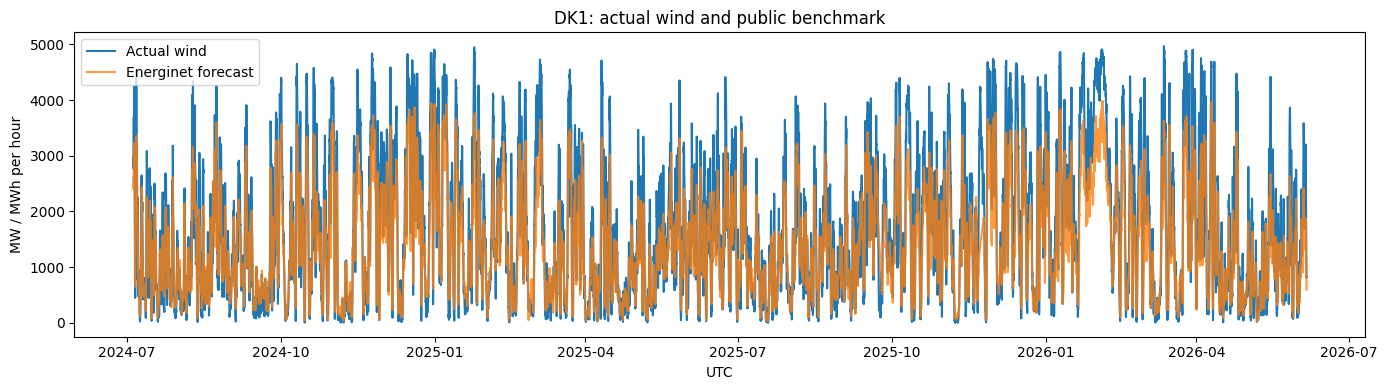

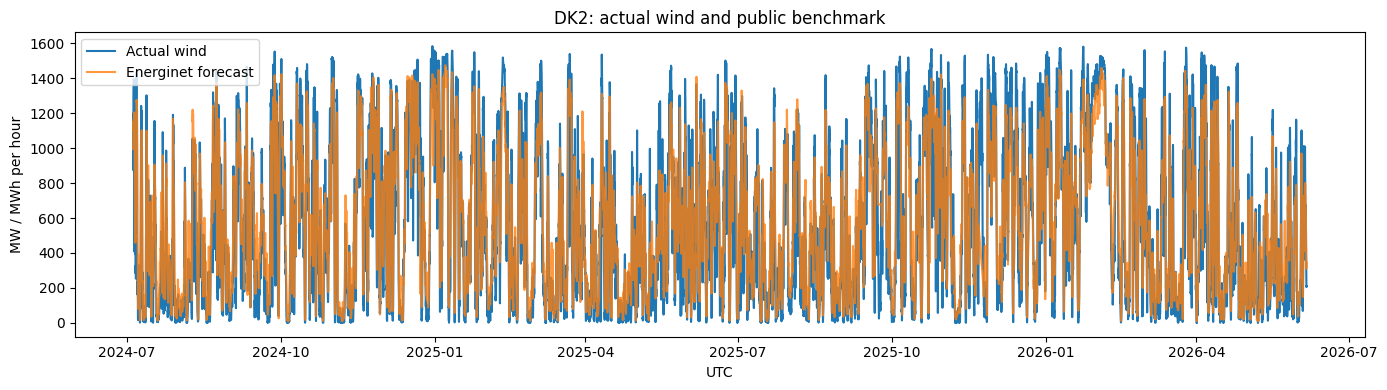

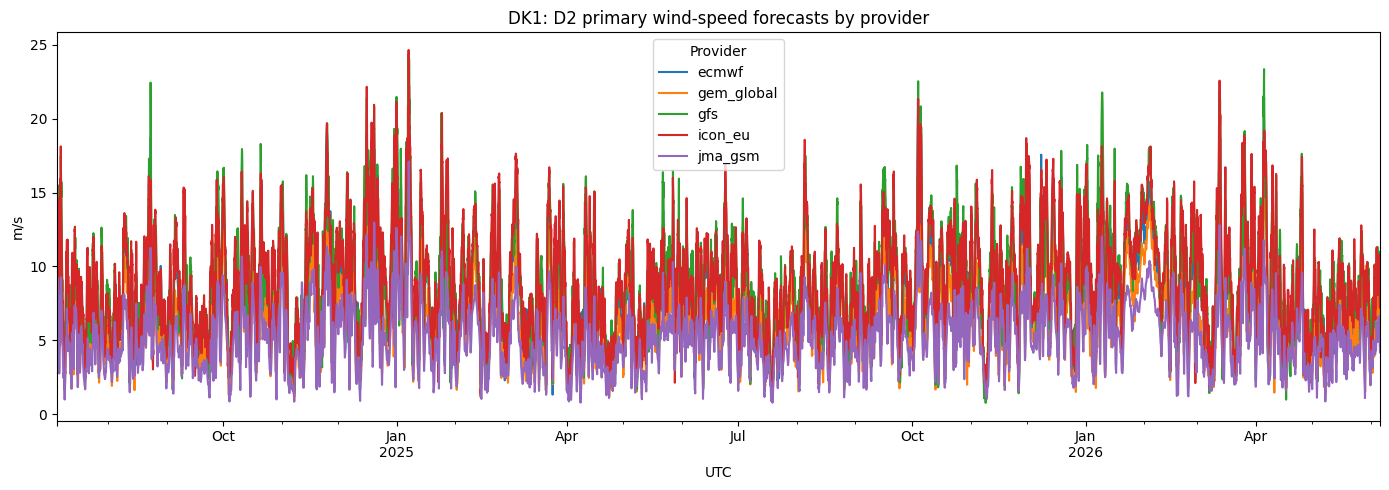

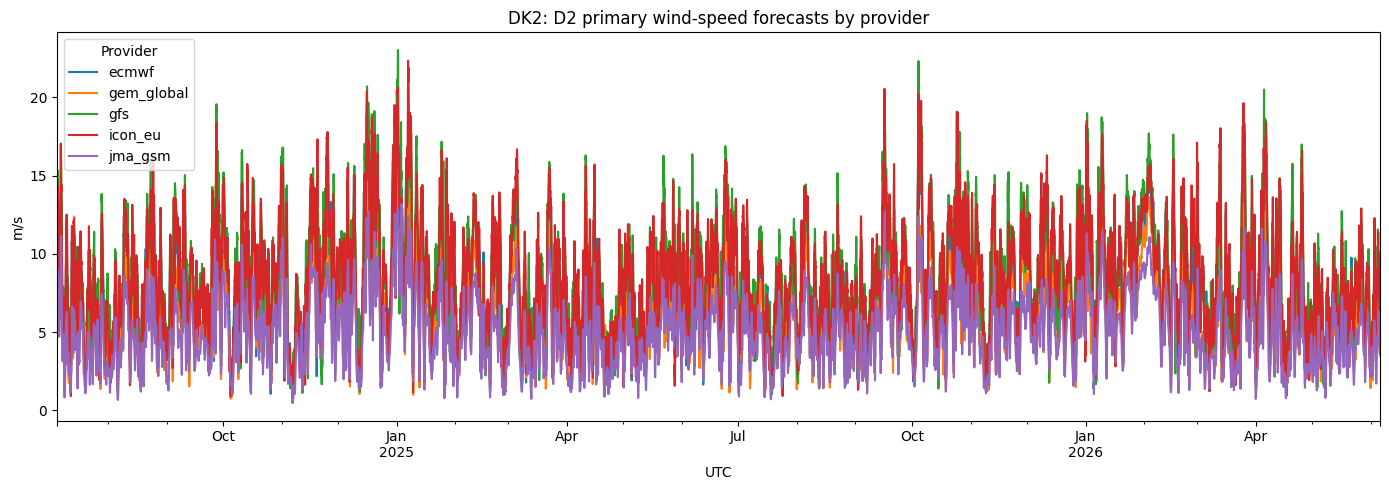

In [27]:
# ============================================================
# VISUALISE ACTUAL WIND, ENERGINET BENCHMARK,
# AND D2 WEATHER-PROVIDER FORECASTS
# ============================================================

# ------------------------------------------------------------
# 1. Actual wind versus Energinet public forecast
# ------------------------------------------------------------

for price_area in PRICE_AREAS:
    area_frame = (
        actual_wind.loc[
            actual_wind["price_area"].eq(price_area)
        ]
        .sort_values("timestamp_utc")
        .copy()
    )

    figure, axis = plt.subplots(
        figsize=(14, 4)
    )

    axis.plot(
        area_frame["timestamp_utc"],
        area_frame["actual_wind_mwh"],
        label="Actual wind",
    )

    if not energinet_wind_forecast.empty:
        benchmark = (
            energinet_wind_forecast.loc[
                energinet_wind_forecast[
                    "price_area"
                ].eq(price_area)
            ]
            .sort_values("timestamp_utc")
            .copy()
        )

        axis.plot(
            benchmark["timestamp_utc"],
            benchmark[
                "energinet_wind_forecast_mw"
            ],
            label="Energinet forecast",
            alpha=0.8,
        )

    axis.set_title(
        f"{price_area}: actual wind and public benchmark"
    )
    axis.set_ylabel("MW / MWh per hour")
    axis.set_xlabel("UTC")
    axis.legend()

    figure.tight_layout()

    figure.savefig(
        FIGURE_DIR
        / (
            f"notebook_01_"
            f"{price_area.lower()}_wind.png"
        ),
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)


# ------------------------------------------------------------
# 2. D2 wind-speed forecasts by weather provider
# ------------------------------------------------------------

weather_value_column = (
    "wind_speed_primary_all"
)

if (
    weather_value_column
    not in selected_previous_runs_area.columns
):
    matching_columns = [
        column
        for column
        in selected_previous_runs_area.columns
        if "wind_speed_primary" in column
    ]

    raise KeyError(
        f"Required column "
        f"{weather_value_column!r} was not found. "
        f"Possible matching columns: "
        f"{matching_columns}"
    )

for price_area in PRICE_AREAS:
    plot_frame = (
        selected_previous_runs_area.loc[
            selected_previous_runs_area[
                "price_area"
            ].eq(price_area)
        ]
        .pivot_table(
            index="timestamp_utc",
            columns="model_alias",
            values=weather_value_column,
            aggfunc="first",
        )
        .sort_index()
    )

    if plot_frame.empty:
        print(
            f"No D2 provider data available for "
            f"{price_area}; skipping plot."
        )
        continue

    axis = plot_frame.plot(
        figsize=(14, 5),
        title=(
            f"{price_area}: D2 primary "
            "wind-speed forecasts by provider"
        ),
    )

    axis.set_ylabel("m/s")
    axis.set_xlabel("UTC")
    axis.legend(
        title="Provider",
        loc="best",
    )

    figure = axis.get_figure()
    figure.tight_layout()

    figure.savefig(
        FIGURE_DIR
        / (
            f"notebook_01_"
            f"{price_area.lower()}_d2_weather.png"
        ),
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

## 16. Save validated outputs and verification report


In [28]:
OUTPUT_FILES = {
    "actual_wind": (
        INTERIM_DIR / "actual_wind_hourly.parquet"
    ),
    "day_ahead_prices": (
        INTERIM_DIR / "day_ahead_prices_hourly.parquet"
    ),
    "imbalance_native": (
        INTERIM_DIR / "imbalance_prices_native.parquet"
    ),
    "imbalance_hourly": (
        INTERIM_DIR / "imbalance_prices_hourly.parquet"
    ),
    "energinet_forecast": (
        INTERIM_DIR
        / "energinet_wind_forecast_hourly.parquet"
    ),
    "previous_runs_point": (
        INTERIM_DIR
        / "weather_previous_runs_d2_point.parquet"
    ),
    "previous_runs_area": (
        INTERIM_DIR
        / "weather_previous_runs_d2_area_long.parquet"
    ),
    "main_model_panel": (
        PROCESSED_DIR
        / "wind_model_panel_d2_hourly.parquet"
    ),
    "actual_wind_exact": (
        INTERIM_DIR / "actual_wind_exact_hourly.parquet"
    ),
    "day_ahead_prices_exact": (
        INTERIM_DIR / "day_ahead_prices_exact_hourly.parquet"
    ),
    "imbalance_hourly_exact": (
        INTERIM_DIR / "imbalance_prices_exact_hourly.parquet"
    ),
    "exact_point": (
        INTERIM_DIR
        / "weather_exact_runs_point.parquet"
    ),
    "exact_area": (
        INTERIM_DIR
        / "weather_exact_runs_area_long.parquet"
    ),
    "exact_model_panel": (
        PROCESSED_DIR
        / "wind_model_panel_exact_runs_hourly.parquet"
    ),
}

actual_wind.to_parquet(
    OUTPUT_FILES["actual_wind"],
    index=False,
)
day_ahead_prices.to_parquet(
    OUTPUT_FILES["day_ahead_prices"],
    index=False,
)

if not imbalance_native.empty:
    imbalance_native.to_parquet(
        OUTPUT_FILES["imbalance_native"],
        index=False,
    )

if not imbalance_hourly.empty:
    imbalance_hourly.to_parquet(
        OUTPUT_FILES["imbalance_hourly"],
        index=False,
    )

if not energinet_wind_forecast.empty:
    energinet_wind_forecast.to_parquet(
        OUTPUT_FILES["energinet_forecast"],
        index=False,
    )

previous_runs_point.to_parquet(
    OUTPUT_FILES["previous_runs_point"],
    index=False,
)
selected_previous_runs_area.to_parquet(
    OUTPUT_FILES["previous_runs_area"],
    index=False,
)
main_model_panel.to_parquet(
    OUTPUT_FILES["main_model_panel"],
    index=False,
)

if not actual_wind_exact.empty:
    actual_wind_exact.to_parquet(
        OUTPUT_FILES["actual_wind_exact"],
        index=False,
    )
if not day_ahead_prices_exact.empty:
    day_ahead_prices_exact.to_parquet(
        OUTPUT_FILES["day_ahead_prices_exact"],
        index=False,
    )
if not imbalance_hourly_exact.empty:
    imbalance_hourly_exact.to_parquet(
        OUTPUT_FILES["imbalance_hourly_exact"],
        index=False,
    )

if not exact_point_forecasts.empty:
    exact_point_forecasts.to_parquet(
        OUTPUT_FILES["exact_point"],
        index=False,
    )
if not exact_area_long.empty:
    exact_area_long.to_parquet(
        OUTPUT_FILES["exact_area"],
        index=False,
    )
if not exact_model_panel.empty:
    exact_model_panel.to_parquet(
        OUTPUT_FILES["exact_model_panel"],
        index=False,
    )

quality_report.to_csv(
    AUDIT_DIR / "notebook_01_quality_report.csv",
    index=False,
)

verification_status = (
    "READY_FOR_FULL_DOWNLOAD"
    if blocking_failures.empty
    and RUN_MODE == "AUDIT"
    else "READY_FOR_MODELLING"
    if blocking_failures.empty
    and RUN_MODE == "FULL"
    else "NOT_READY"
)

verification_report = {
    "verification_status": verification_status,
    "run_mode": RUN_MODE,
    "main_start_local": START_LOCAL.isoformat(),
    "main_end_local_exclusive": END_LOCAL.isoformat(),
    "main_lead_definition": (
        f"previous_day{PREVIOUS_RUN_DAY}"
    ),
    "selected_main_sources": SELECTED_MAIN_SOURCES,
    "source_coverage": (
        main_weather_coverage.to_dict(
            orient="records"
        )
    ),
    "common_panel_retention": (
        common_panel_retention
    ),
    "actual_wind_rows": len(actual_wind),
    "day_ahead_rows": len(day_ahead_prices),
    "imbalance_native_rows": len(
        imbalance_native
    ),
    "energinet_forecast_rows": len(
        energinet_wind_forecast
    ),
    "previous_runs_point_rows": len(
        previous_runs_point
    ),
    "previous_runs_area_rows": len(
        selected_previous_runs_area
    ),
    "main_model_panel_shape": list(
        main_model_panel.shape
    ),
    "exact_start_local": (
        EXACT_START_LOCAL.isoformat()
        if RUN_EXACT_ROBUSTNESS
        else None
    ),
    "exact_end_local_exclusive": (
        EXACT_END_LOCAL.isoformat()
        if RUN_EXACT_ROBUSTNESS
        else None
    ),
    "selected_exact_sources": (
        SELECTED_EXACT_SOURCES
        if RUN_EXACT_ROBUSTNESS
        else []
    ),
    "exact_source_coverage": (
        exact_source_coverage.to_dict(
            orient="records"
        )
        if RUN_EXACT_ROBUSTNESS
        else []
    ),
    "exact_target_rows": len(
        actual_wind_exact
    ),
    "exact_weather_point_rows": len(
        exact_point_forecasts
    ),
    "exact_weather_area_rows": len(
        exact_area_long
    ),
    "exact_model_panel_shape": list(
        exact_model_panel.shape
    ),
    "previous_runs_errors": (
        previous_runs_errors
    ),
    "exact_run_errors": exact_errors,
    "energinet_forecast_error": (
        energinet_forecast_error
    ),
    "blocking_failures": (
        blocking_failures.to_dict(
            orient="records"
        )
    ),
    "output_files": {
        key: {
            "path": str(path),
            "exists": path.exists(),
            "size_mb": (
                round(
                    path.stat().st_size
                    / (1024 ** 2),
                    3,
                )
                if path.exists()
                else None
            ),
        }
        for key, path in OUTPUT_FILES.items()
    },
}

with (
    AUDIT_DIR
    / "notebook_01_verification.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        verification_report,
        file,
        indent=2,
        default=str,
    )

print("=== NOTEBOOK 01 VERIFICATION ===")
print(
    json.dumps(
        verification_report,
        indent=2,
        default=str,
    )
)
print("=== END VERIFICATION ===")


=== NOTEBOOK 01 VERIFICATION ===
{
  "verification_status": "READY_FOR_MODELLING",
  "run_mode": "FULL",
  "main_start_local": "2024-07-05T00:00:00+02:00",
  "main_end_local_exclusive": "2026-06-06T00:00:00+02:00",
  "main_lead_definition": "previous_day2",
  "selected_main_sources": [
    "gfs",
    "icon_eu",
    "ecmwf",
    "gem_global",
    "jma_gsm"
  ],
  "source_coverage": [
    {
      "model_alias": "gfs",
      "api_model": "gfs_global",
      "provider": "NOAA",
      "required": true,
      "coverage_wind_100m": 1.0,
      "coverage_wind_10m": 1.0,
      "selected_wind_height": "100m",
      "primary_wind_coverage": 1.0,
      "selection_threshold": 0.99,
      "selected": true
    },
    {
      "model_alias": "icon_eu",
      "api_model": "icon_eu",
      "provider": "DWD",
      "required": true,
      "coverage_wind_100m": 1.0,
      "coverage_wind_10m": 1.0,
      "selected_wind_height": "100m",
      "primary_wind_coverage": 1.0,
      "selection_threshold": 0.99,
  

In [29]:
# ============================================================
# FINALISE CANONICAL EXACT-RUN OUTPUTS
# ============================================================

canonical_exact_path = (
    PROCESSED_DIR
    / "wind_model_panel_exact_runs_hourly.parquet"
)

strict_exact_path = (
    PROCESSED_DIR
    / (
        "wind_model_panel_exact_runs_"
        "seven_source_common_hourly.parquet"
    )
)

all_available_exact_path = (
    PROCESSED_DIR
    / (
        "wind_model_panel_exact_runs_"
        "all_available_hourly.parquet"
    )
)

# Save both research variants explicitly.
exact_model_panel_common.to_parquet(
    strict_exact_path,
    index=False,
)

exact_model_panel_all_available.to_parquet(
    all_available_exact_path,
    index=False,
)

# Make the canonical downstream file the strict panel.
exact_model_panel_common.to_parquet(
    canonical_exact_path,
    index=False,
)

# Reload from disk to verify what future notebooks will receive.
canonical_disk = pd.read_parquet(
    canonical_exact_path
)

strict_disk = pd.read_parquet(
    strict_exact_path
)

all_available_disk = pd.read_parquet(
    all_available_exact_path
)

assert canonical_disk.shape == exact_model_panel_common.shape
assert strict_disk.shape == exact_model_panel_common.shape
assert (
    all_available_disk.shape
    == exact_model_panel_all_available.shape
)

assert (
    canonical_disk.duplicated(
        [
            "timestamp_utc",
            "price_area",
        ]
    ).sum()
    == 0
)

assert len(canonical_disk) == 9458
assert len(all_available_disk) == 10704

print(
    "Canonical exact panel:",
    canonical_exact_path,
)

print(
    "Canonical shape:",
    canonical_disk.shape,
)

print(
    "Strict shape:",
    strict_disk.shape,
)

print(
    "All-available shape:",
    all_available_disk.shape,
)

print(
    "Notebook 01 finalised successfully."
)

Canonical exact panel: C:\Users\chka24ac\Nordic Wind Decision System\data\processed\wind_model_panel_exact_runs_hourly.parquet
Canonical shape: (9458, 315)
Strict shape: (9458, 315)
All-available shape: (10704, 315)
Notebook 01 finalised successfully.


## Acceptance gate

Proceed to Notebook 02 only when:

- the audit run returns `READY_FOR_FULL_DOWNLOAD`;
- the full run returns `READY_FOR_MODELLING`;
- at least three homogeneous D2 wind providers pass;
- exact-run providers are selected independently from exact coverage;
- the exact-period target and weather panel are both non-empty;
- all selected exact runs satisfy the information-time contract.

The full download should be started only after this revised audit passes.
